# New personas at Bene Bono

See my medium article here :

This is the code used to create new personas at Bene Bono. There is two parts :
- Creating the clusters
- Analysing the clusters

# Cleaning, PCA, Elbow Curve, K-means



--- Initial Data Overview ---
First 5 rows:
   Customer ID             Created At: Day  Has Mobile App  \
0       125521  Saturday, February 1, 2025            True   
1       125527  Saturday, February 1, 2025            True   
2       125530  Saturday, February 1, 2025            True   
3       125531  Saturday, February 1, 2025            True   
4       125534  Saturday, February 1, 2025            True   

   Notification Status App Version Android App Version iOS  \
0                  NaN                 NaN             NaN   
1                  NaN                 NaN             NaN   
2                  NaN              2.33.0             NaN   
3                  NaN                 NaN          2.30.8   
4                  NaN                 NaN             NaN   

        Last Order Date: Day Delivery Method  Delivery Zipcode  Departement  \
0  Sunday, February 16, 2025        delivery             69009           69   
1  Sunday, February 16, 2025        delivery        

<ipython-input-42-65d7a349c9f5>:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Spent'].fillna(median_total_spent, inplace=True)


\nShape of data after PCA: (2000, 57)
Number of components selected by PCA: 57
Explained variance ratio by selected components: 0.95

--- Generating Scree plot ---
Scree plot generated as scree_plot.png
\nElbow method plot generated as elbow_plot.png.
\nProceeding with K=4 clusters for persona generation.
\n--- Cluster Distribution (K=4) ---
cluster
0    862
1    302
2    414
3    422
Name: count, dtype: int64
\n--- Cluster Profiles (based on imputed, non-scaled/encoded data) ---
\n--- Profile for Cluster 0 ---
\n  Numerical Feature Means:
    Delivery Zipcode: 79688.71
    Departement: 79.53
    Num Total Orders: 1.83
    Total Spent: 74.81
    AOV: 43.39
    Frequency: 3.63
    Order Details - Order → Pre Selection Children: 0.10
    Order Details - Order → Pre Selection Adults: 1.45
    Order Details - Order → Pre Selection Household: 1.50
    Order Details - Order → Pre Selection Amout Min (€): 37.83
    Order Details - Order → Pre Selection Amout Max (€): 42.26
\n  Categorical Fea

<ipython-input-42-65d7a349c9f5>:172: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_interpretable[col].fillna(df_interpretable[col].median(), inplace=True)
<ipython-input-42-65d7a349c9f5>:175: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

\nCluster plot based on first two PCA components generated as pca_clusters.png.
Numerical profile plot generated as numerical_profile_plot.png.
Categorical profile plot for Delivery Method generated as categorical_delivery_method_plot.png.
\n--- Analysis Complete ---
Review the 'Cluster Profiles' text output above and the generated PNG images to build your personas.


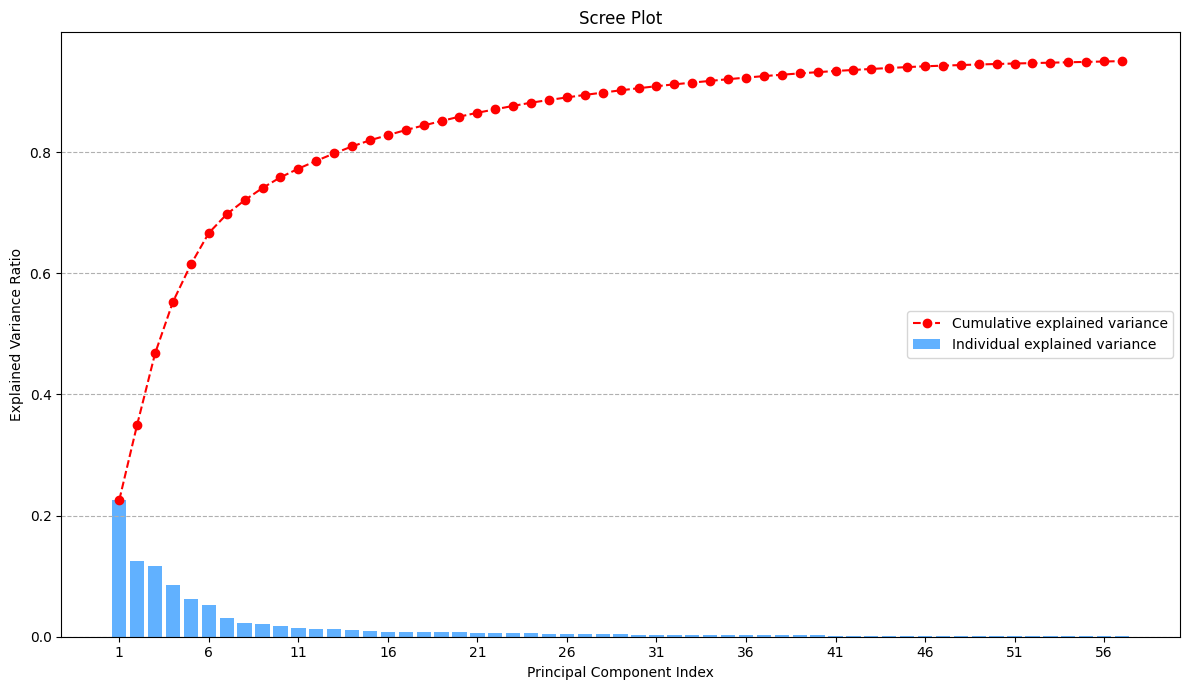

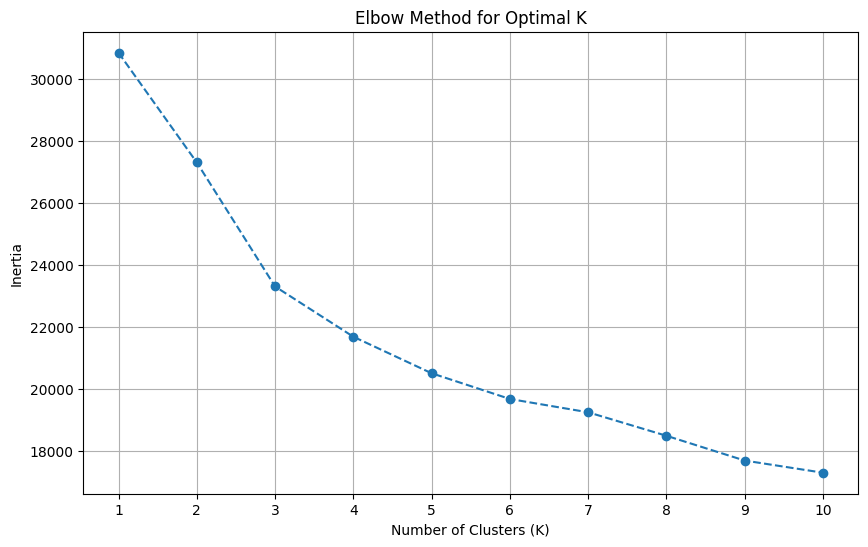

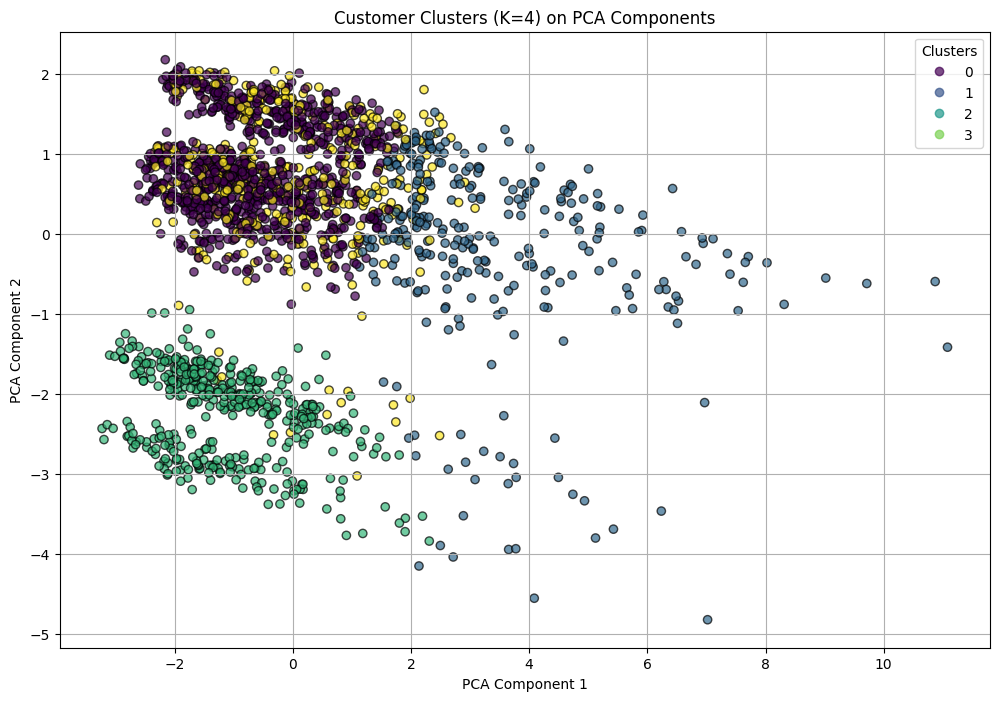

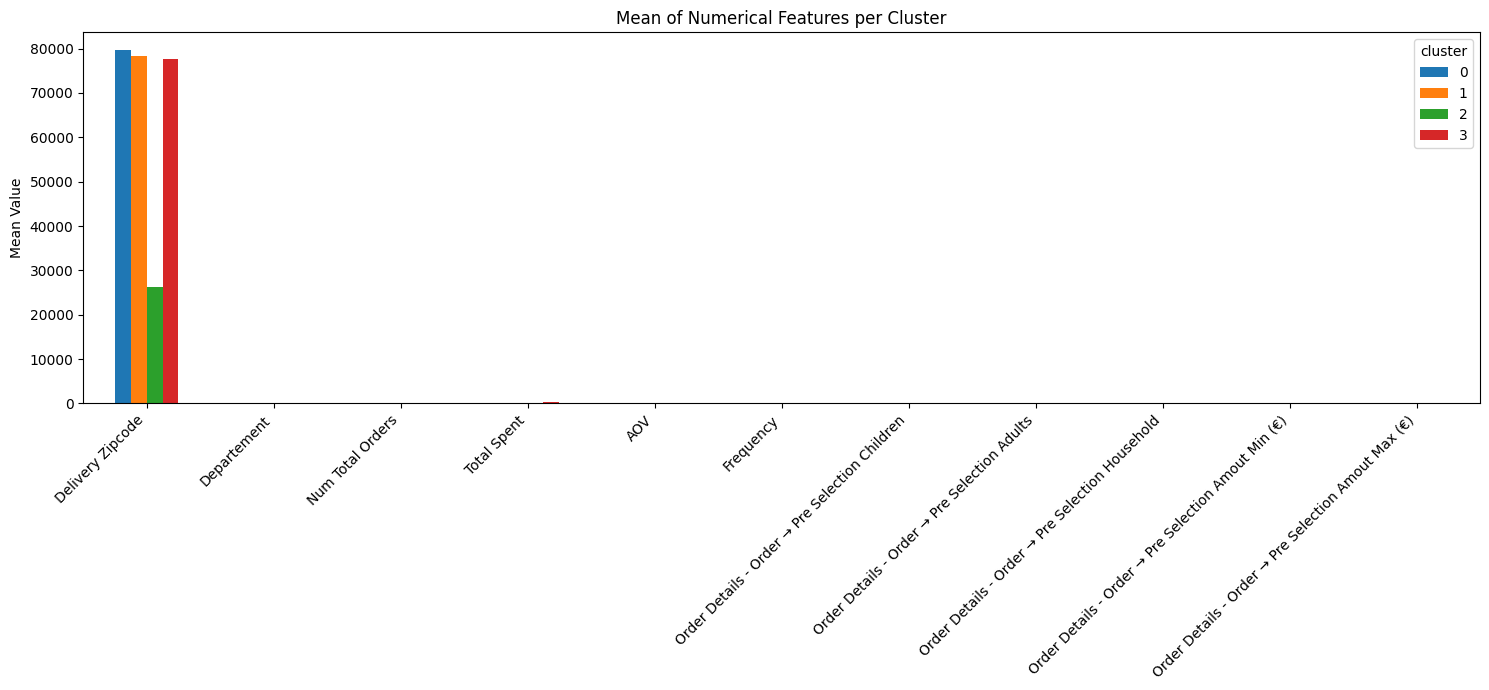

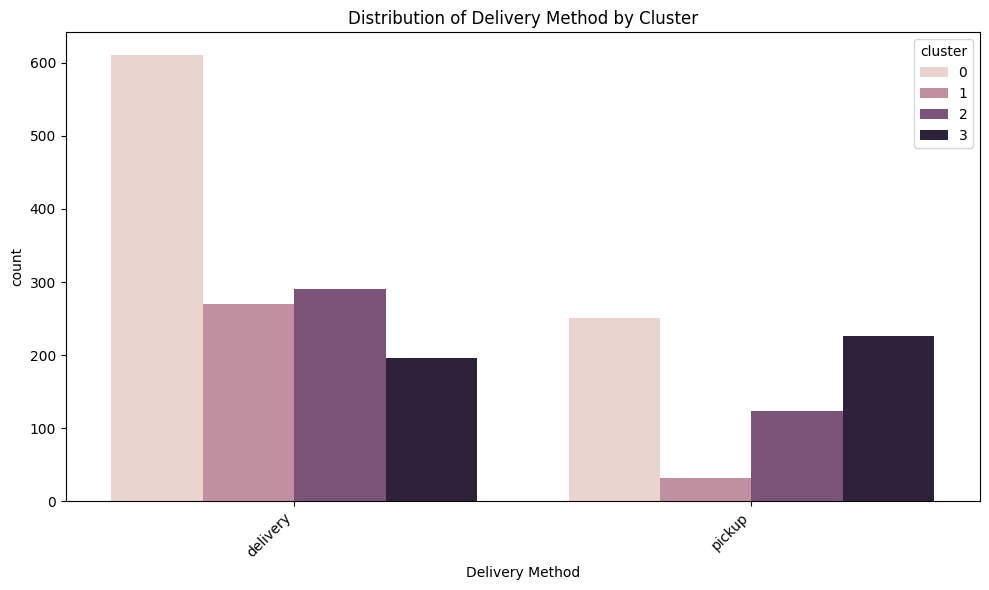

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import numpy as np

# Load the dataset
file_path = "/content/download (9).csv"
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded correctly.")
    exit()

print("--- Initial Data Overview ---")
print("First 5 rows:")
print(df.head())
# df.info() # Suppressing for brevity in this run, was checked before

# --- Data Cleaning and Preprocessing ---

# Convert 'Total Spent' to numeric, coercing errors
if 'Total Spent' in df.columns:
    df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')
    if df['Total Spent'].isnull().any(): # Check if any NaNs were created
        median_total_spent = df['Total Spent'].median()
        df['Total Spent'].fillna(median_total_spent, inplace=True)
        print(f"Filled NaNs in 'Total Spent' with median: {median_total_spent}")


# Define columns to drop
cols_to_drop = [
    'Customer ID',
    'Notification Status',
    'Checkouts - Customer → Heard About Us',
    'Checkouts - Customer → Motivations',
    'Last Churn Free Text',
    'Created At: Day', 'Last Order Date: Day', 'Last Churn Date: Day',
    'App Version Android', 'App Version iOS',
    #'TimeDiff',
    #'Delivery Zipcode',
    #'Departement'
]
df_processed = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')


numerical_cols = df_processed.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"\\nNumerical columns selected: {numerical_cols}")
print(f"Categorical columns selected: {categorical_cols}")

# Create preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')) # drop='first' to reduce multicollinearity
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

X_processed = None
try:
    X_processed = preprocessor.fit_transform(df_processed)
    # Get feature names after one-hot encoding
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    all_feature_names = numerical_cols + list(ohe_feature_names)
    X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)
    print(f"\\nShape of processed data: {X_processed_df.shape}")
    # print("First 5 rows of processed data:") # Suppressing for brevity
    # print(X_processed_df.head())
except Exception as e:
    print(f"An error occurred during preprocessing: {e}")
    # Fallback for older sklearn versions or if get_feature_names_out fails with drop='first' context
    if X_processed is not None: # if fit_transform worked but getting names failed.
        print(f"\\nShape of processed data: {X_processed.shape} (Could not retrieve all feature names for DataFrame header due to: {e})")
    else:
        print("Preprocessing failed, cannot continue.")
        exit()


# --- Dimensionality Reduction (PCA) ---
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_processed)

print(f"\\nShape of data after PCA: {X_pca.shape}")
print(f"Number of components selected by PCA: {pca.n_components_}")
print(f"Explained variance ratio by selected components: {sum(pca.explained_variance_ratio_):.2f}")


# --- Scree Plot Generation (NEW SECTION) ---
print("\n--- Generating Scree plot ---")
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
# Number of components to plot (could be all components pca.components_ or just the ones selected by n_components=0.95)
# For the plot, it's usually best to show all or a significant number if there are too many.
# Here, we plot for the number of components determined by PCA (up to where 95% variance is explained).
n_components_to_plot_scree = pca.n_components_ # This is the number of components PCA decided on for 0.95 variance

plt.figure(figsize=(12, 7)) # Adjusted figure size for better readability
# Bar plot for individual variance
plt.bar(range(1, n_components_to_plot_scree + 1), explained_variance[:n_components_to_plot_scree], alpha=0.7,
        align='center', label='Individual explained variance', color='dodgerblue')
# Line plot for cumulative variance
plt.plot(range(1, n_components_to_plot_scree + 1), cumulative_variance[:n_components_to_plot_scree],
         marker='o', linestyle='--', color='red', label='Cumulative explained variance')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot')
# Adjust x-ticks if there are too many components to display clearly
if n_components_to_plot_scree > 20: # Example threshold
    tick_interval = max(1, n_components_to_plot_scree // 10) # Show about 10 ticks
    plt.xticks(ticks=np.arange(1, n_components_to_plot_scree + 1, tick_interval))
else:
    plt.xticks(ticks=range(1, n_components_to_plot_scree + 1))

plt.legend(loc='center right') # Adjusted legend location
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
output_scree_plot_filename = "scree_plot.png"
plt.savefig(output_scree_plot_filename)
print(f"Scree plot generated as {output_scree_plot_filename}")
# --- End of Scree Plot Generation ---



# --- Determine Optimal Number of Clusters (K-Means) ---
inertia = []
k_range = range(1, 11)
for k_val in k_range:
    kmeans_elbow = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    kmeans_elbow.fit(X_pca)
    inertia.append(kmeans_elbow.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.savefig("elbow_plot.png")
print("\\nElbow method plot generated as elbow_plot.png.")

chosen_k = 4
print(f"\\nProceeding with K={chosen_k} clusters for persona generation.")

kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_pca)

# Prepare df_interpretable for profiling (imputed original values)
df_interpretable = df_processed.copy()

for col in numerical_cols:
    if df_interpretable[col].isnull().any():
        df_interpretable[col].fillna(df_interpretable[col].median(), inplace=True)
for col in categorical_cols:
    if df_interpretable[col].isnull().any():
        df_interpretable[col].fillna(df_interpretable[col].mode()[0], inplace=True)

df_interpretable['cluster'] = cluster_labels

print(f"\\n--- Cluster Distribution (K={chosen_k}) ---")
print(df_interpretable['cluster'].value_counts().sort_index())

print("\\n--- Cluster Profiles (based on imputed, non-scaled/encoded data) ---")
for i in range(chosen_k):
    print(f"\\n--- Profile for Cluster {i} ---")
    cluster_data = df_interpretable[df_interpretable['cluster'] == i]
    if cluster_data.empty:
        print("  This cluster is empty.")
        continue

    print("\\n  Numerical Feature Means:")
    for col in numerical_cols:
        if col in cluster_data.columns: # Ensure column exists
            mean_val = cluster_data[col].mean()
            print(f"    {col}: {mean_val:.2f}")

    print("\\n  Categorical Feature Modes:")
    for col in categorical_cols:
        if col in cluster_data.columns: # Ensure column exists
            mode_series = cluster_data[col].mode()
            mode_val = mode_series[0] if not mode_series.empty else "N/A"
            print(f"    {col} (Mode): {mode_val}")


# --- Visualizations ---


#PC1 vs PC2
if X_pca.shape[1] >= 2:
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7, edgecolors='k')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title(f'Customer Clusters (K={chosen_k}) on PCA Components')
    plt.legend(handles=scatter.legend_elements(num=chosen_k)[0] if chosen_k >0 else [], labels=range(chosen_k), title="Clusters")
    plt.grid(True)
    plt.savefig("pca_clusters.png")
    print("\\nCluster plot based on first two PCA components generated as pca_clusters.png.")

# Numerical feature means by cluster plot
valid_numerical_cols_for_plot = [col for col in numerical_cols if col in df_interpretable.columns]
if valid_numerical_cols_for_plot:
    try:
        cluster_numerical_summary = df_interpretable.groupby('cluster')[valid_numerical_cols_for_plot].mean()
        cluster_numerical_summary.T.plot(kind='bar', figsize=(15, 7))
        plt.title('Mean of Numerical Features per Cluster')
        plt.ylabel('Mean Value')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig("numerical_profile_plot.png")
        print("Numerical profile plot generated as numerical_profile_plot.png.")
    except Exception as e:
        print(f"Could not generate numerical profile plot: {e}")
else:
    print("No valid numerical columns found for profile plot after checks.")


# Example categorical plot
key_categorical_for_plot = 'Delivery Method'
if key_categorical_for_plot in categorical_cols and key_categorical_for_plot in df_interpretable.columns:
    plt.figure(figsize=(10, 6))
    # Ensure there's data to plot
    if not df_interpretable[df_interpretable['cluster'].notna()].empty:
        sns.countplot(data=df_interpretable, x=key_categorical_for_plot, hue='cluster',
                      order=df_interpretable[key_categorical_for_plot].value_counts().index)
        plt.title(f'Distribution of {key_categorical_for_plot} by Cluster')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f"categorical_{key_categorical_for_plot.replace(' ', '_').lower()}_plot.png")
        print(f"Categorical profile plot for {key_categorical_for_plot} generated as categorical_{key_categorical_for_plot.replace(' ', '_').lower()}_plot.png.")
    else:
        print(f"Not enough data to plot categorical feature {key_categorical_for_plot}")


print("\\n--- Analysis Complete ---")
print("Review the 'Cluster Profiles' text output above and the generated PNG images to build your personas.")


--- PCA Loading Scores ---
Les loadings indiquent le poids de chaque variable pour chaque composante principale.
Une valeur proche de 1 ou -1 indique une forte influence.

--- Variables les plus influentes par Composante Principale ---

--- PC1 ---
Order Details - Order → Pre Selection Amout Min (€)    0.447221
Order Details - Order → Pre Selection Amout Max (€)    0.444562
AOV                                                    0.407937
Order Details - Order → Pre Selection Household        0.386338
Order Details - Order → Pre Selection Adults           0.318707
Order Details - Order → Pre Selection Children         0.273581
Total Spent                                            0.207076
Delivery Zipcode                                       0.152482
Departement                                            0.151926
Delivery Method_pickup                                -0.068645
Name: PC1, dtype: float64

--- PC2 ---
Departement                                            0.665501
Deliver

<ipython-input-30-a15d21f4aa98>:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # Ajuste automatiquement la mise en page



Une heatmap des loadings a été générée sous 'pca_loadings_heatmap.png'.


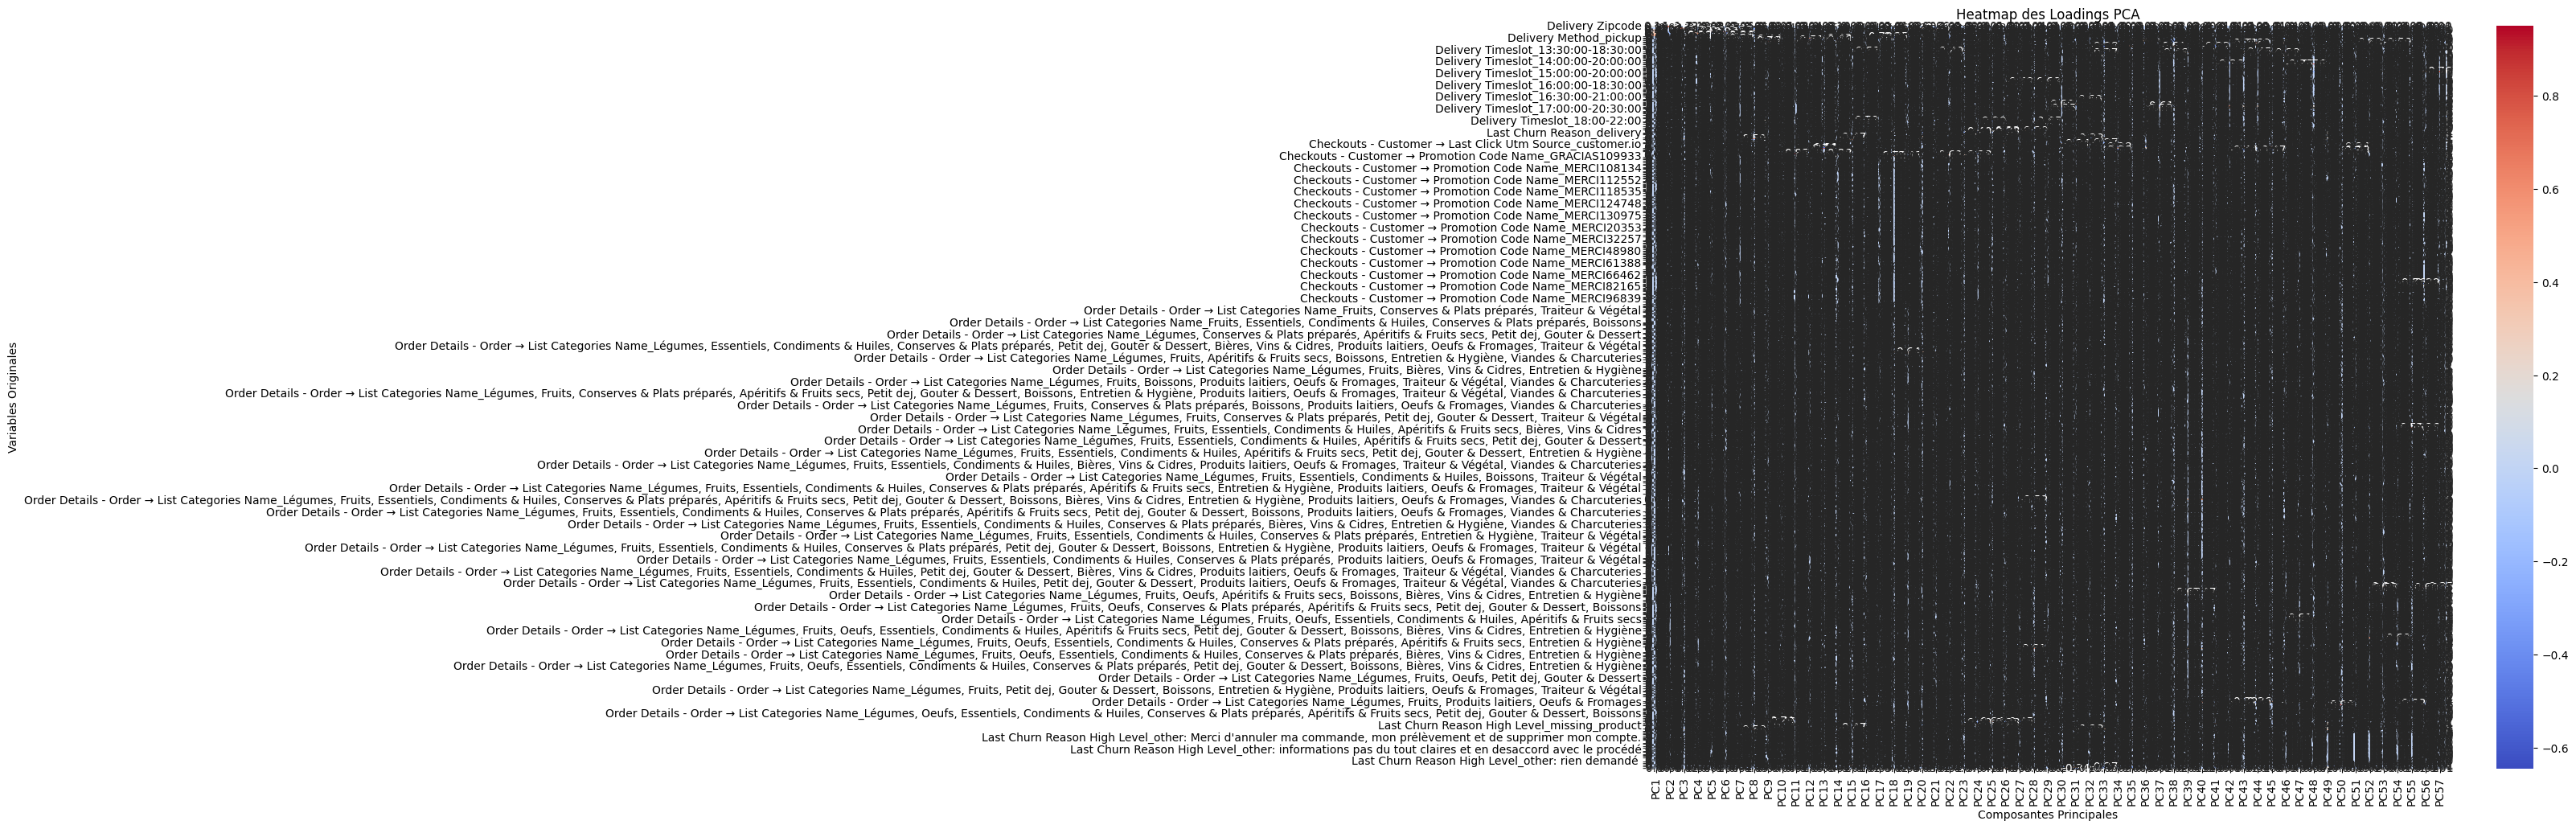

In [ ]:
# Créer un DataFrame avec les loadings
# Les loadings sont stockés dans pca.components_
# La forme est (n_components, n_features), nous la transposons pour une meilleure lecture
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Noms des colonnes : PC1, PC2...
    index=all_feature_names  # Noms des variables originales (après One-Hot Encoding)
)

print("\n--- PCA Loading Scores ---")
print("Les loadings indiquent le poids de chaque variable pour chaque composante principale.")
print("Une valeur proche de 1 ou -1 indique une forte influence.")
# print(loadings_df) # Décommentez si vous voulez voir la table complète

# Afficher les variables les plus importantes pour chaque composante
print("\n--- Variables les plus influentes par Composante Principale ---")
for column in loadings_df.columns:
    print(f"\n--- {column} ---")
    # Trier par la valeur absolue pour voir les variables les plus influentes (positives ou négatives)
    sorted_loadings = loadings_df[column].abs().sort_values(ascending=False)
    # Afficher le top 10 des variables pour cette composante
    print(loadings_df[column].loc[sorted_loadings.index].head(10))

# Visualisation des loadings avec une heatmap
# C'est souvent plus simple pour interpréter les résultats d'un seul coup d'oeil
plt.figure(figsize=(16, 12)) # N'hésitez pas à ajuster la taille
sns.heatmap(loadings_df, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Heatmap des Loadings PCA')
plt.ylabel('Variables Originales')
plt.xlabel('Composantes Principales')
plt.tight_layout() # Ajuste automatiquement la mise en page
plt.savefig("pca_loadings_heatmap.png")
print("\nUne heatmap des loadings a été générée sous 'pca_loadings_heatmap.png'.")

# Graphs

Création de graphs et données numériques sur une data clean

Voir cette question metabase

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

In [ ]:


# Load the dataset
file_path = "/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv"
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded correctly.")
    exit()

print("--- Initial Data Overview ---")
print("First 5 rows:")
print(df.head())
# df.info() # Suppressing for brevity in this run, was checked before

--- Initial Data Overview ---
First 5 rows:
   Customer ID              Created At: Day  Has Mobile App  \
0         6728    Tuesday, January 18, 2022            True   
1         6734    Tuesday, January 18, 2022            True   
2         6735    Tuesday, January 18, 2022           False   
3         6740  Wednesday, January 19, 2022            True   
4         6744  Wednesday, January 19, 2022           False   

  Notification Status App Version Android App Version iOS  \
0             granted              2.35.7             NaN   
1              denied              2.35.1             NaN   
2                 NaN                 NaN             NaN   
3             granted              2.35.7             NaN   
4                 NaN                 NaN             NaN   

         Last Order Date: Day Delivery Method  Delivery Zipcode  Departement  \
0       Sunday, June 15, 2025          pickup           75010.0         75.0   
1       Sunday, June 15, 2025          pickup     

/tmp/ipython-input-26-3222738532.py:4: DtypeWarning: Columns (3,16,18,19,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [ ]:


# ---Nombre de clusters ---
chosen_k = 3
print(f"\\nProceeding with K={chosen_k} clusters for persona generation.")


# --- Data Cleaning and Preprocessing ---

# --- Définition manuelle des colonnes à conserver ---

numerical_cols = [
    "Num Total Orders",
    "Total Spent",
    "AOV",
    "frequency1",
    "Order Details - Order → Pre Selection Adults",
    "Order Details - Order → Pre Selection Children",
    "Order Details - Order → Pre Selection Amout Min (€)",
    "Order Details - Order → Pre Selection Amout Max (€)",
    "densite"
]

categorical_cols = [
    "Has Mobile App",
    "Departement",
    "Delivery Method",
    "Order Details - Order → Smartcart Criteria Bio"
]

all_cols_to_keep = numerical_cols + categorical_cols

# --- MODIFICATION 2 : Vérification de la présence des colonnes ---
# Ajout d'une sécurité pour vérifier que les colonnes existent bien dans le fichier
missing_cols = [col for col in all_cols_to_keep if col not in df.columns]
if missing_cols:
    print(f"ERREUR : Les colonnes suivantes sont introuvables dans votre fichier CSV : {missing_cols}")
    print("Veuillez vérifier les noms des colonnes.")
    exit()

# --- MODIFICATION 3 : Création du DataFrame traité en sélectionnant UNIQUEMENT les colonnes voulues ---
# Au lieu de supprimer des colonnes, on ne garde que celles de notre liste.
df_processed = df[all_cols_to_keep].copy() # .copy() pour éviter les avertissements

# --- Traitement des valeurs manquantes ou erronées ---
# Conversion de 'Total Spent' en numérique, en forçant les erreurs
if 'Total Spent' in df_processed.columns:
    df_processed['Total Spent'] = pd.to_numeric(df_processed['Total Spent'], errors='coerce')

# Pour les variables numériques où NaN signifie "non utilisé"
df_processed["Order Details - Order → Pre Selection Adults"].fillna(0, inplace=True)
df_processed["Order Details - Order → Pre Selection Children"].fillna(0, inplace=True)
print("Remplacement des NaNs par 0 dans les colonnes 'Pre Selection'.")

# Pour la variable catégorielle où NaN signifie "non spécifié"
df_processed["Order Details - Order → Smartcart Criteria Bio"].fillna("Non spécifié", inplace=True)
print("Remplacement des NaNs par 'Non spécifié' dans la colonne 'Smartcart Criteria Bio'.")


# Le reste de votre code (Pipelines, ColumnTransformer, etc.) reste identique.
# Les imputers 'median' et 'most_frequent' dans vos pipelines serviront désormais
# de sécurité pour d'éventuelles autres valeurs manquantes que vous n'auriez pas prévues.

# --- Traitement des valeurs erronées (comme vous l'aviez fait) ---
# Conversion de 'Total Spent' en numérique, en forçant les erreurs
if 'Total Spent' in df_processed.columns:
    df_processed['Total Spent'] = pd.to_numeric(df_processed['Total Spent'], errors='coerce')

print(f"\nColonnes numériques sélectionnées : {numerical_cols}")
print(f"Colonnes catégorielles sélectionnées : {categorical_cols}")



# Le reste du code reste identique, car il utilise les listes `numerical_cols` et `categorical_cols`
# que nous venons de définir manuellement.

# Create preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)


X_processed = None
try:
    X_processed = preprocessor.fit_transform(df_processed)
    # Get feature names after one-hot encoding
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    all_feature_names = numerical_cols + list(ohe_feature_names)
    X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)
    print(f"\\nShape of processed data: {X_processed_df.shape}")
    # print("First 5 rows of processed data:") # Suppressing for brevity
    # print(X_processed_df.head())
except Exception as e:
    print(f"An error occurred during preprocessing: {e}")
    # Fallback for older sklearn versions or if get_feature_names_out fails with drop='first' context
    if X_processed is not None: # if fit_transform worked but getting names failed.
        print(f"\\nShape of processed data: {X_processed.shape} (Could not retrieve all feature names for DataFrame header due to: {e})")
    else:
        print("Preprocessing failed, cannot continue.")
        exit()


# --- Dimensionality Reduction (PCA) ---
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_processed)

print(f"\\nShape of data after PCA: {X_pca.shape}")
print(f"Number of components selected by PCA: {pca.n_components_}")
print(f"Explained variance ratio by selected components: {sum(pca.explained_variance_ratio_):.2f}")


# --- Scree Plot Generation (NEW SECTION) ---
print("\n--- Generating Scree plot ---")
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
# Number of components to plot (could be all components pca.components_ or just the ones selected by n_components=0.95)
# For the plot, it's usually best to show all or a significant number if there are too many.
# Here, we plot for the number of components determined by PCA (up to where 95% variance is explained).
n_components_to_plot_scree = pca.n_components_ # This is the number of components PCA decided on for 0.95 variance

plt.figure(figsize=(12, 7)) # Adjusted figure size for better readability
# Bar plot for individual variance
plt.bar(range(1, n_components_to_plot_scree + 1), explained_variance[:n_components_to_plot_scree], alpha=0.7,
        align='center', label='Individual explained variance', color='dodgerblue')
# Line plot for cumulative variance
plt.plot(range(1, n_components_to_plot_scree + 1), cumulative_variance[:n_components_to_plot_scree],
         marker='o', linestyle='--', color='red', label='Cumulative explained variance')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot')
# Adjust x-ticks if there are too many components to display clearly
if n_components_to_plot_scree > 20: # Example threshold
    tick_interval = max(1, n_components_to_plot_scree // 10) # Show about 10 ticks
    plt.xticks(ticks=np.arange(1, n_components_to_plot_scree + 1, tick_interval))
else:
    plt.xticks(ticks=range(1, n_components_to_plot_scree + 1))

plt.legend(loc='center right') # Adjusted legend location
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
output_scree_plot_filename = "scree_plot.png"
plt.savefig(output_scree_plot_filename)
print(f"Scree plot generated as {output_scree_plot_filename}")
# --- End of Scree Plot Generation ---



# --- Determine Optimal Number of Clusters (K-Means) ---
inertia = []
k_range = range(1, 11)
for k_val in k_range:
    kmeans_elbow = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    kmeans_elbow.fit(X_pca)
    inertia.append(kmeans_elbow.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.savefig("elbow_plot.png")
print("\\nElbow method plot generated as elbow_plot.png.")

'''
###########################################
# --- Silhouette Analysis---
###########################################
silhouette_scores = []
silhouette_range = range(2, 11)  # Le score de Silhouette n'est pas défini pour k=1

for k_val in silhouette_range:
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"Silhouette score for k={k_val}: {score:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(silhouette_range, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis For Optimal K')
plt.xticks(silhouette_range)
plt.grid(True)
plt.savefig("silhouette_plot.png")
print("Silhouette analysis plot generated as silhouette_plot.png.")

# Optionnel : afficher le score pour le k retenu
if chosen_k in silhouette_range:
    idx = list(silhouette_range).index(chosen_k)
    print(f"\nSilhouette score for chosen_k={chosen_k}: {silhouette_scores[idx]:.3f}")
'''

kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_pca)

# Prepare df_interpretable for profiling (imputed original values)
df_interpretable = df_processed.copy()
print("\n--- Imputing missing values for final interpretation ---")


for col in numerical_cols:
    # On vérifie s'il y a des valeurs manquantes à traiter
    if df_interpretable[col].isnull().any():
        median_val = df_interpretable[col].median()
        # On utilise l'assignation directe pour éviter le FutureWarning
        df_interpretable[col] = df_interpretable[col].fillna(median_val)
        # print(f"Missing values in '{col}' filled with median: {median_val:.2f}") # Décommentez pour vérifier

for col in categorical_cols:
    if df_interpretable[col].isnull().any():
        mode_val = df_interpretable[col].mode()[0]
        # On utilise l'assignation directe ici aussi
        df_interpretable[col] = df_interpretable[col].fillna(mode_val)
        # print(f"Missing values in '{col}' filled with mode: {mode_val}") # Décommentez pour vérifier

# Ajout des labels de cluster au DataFrame
df_interpretable['cluster'] = cluster_labels


print(f"\\n--- Cluster Distribution (K={chosen_k}) ---")
print(df_interpretable['cluster'].value_counts().sort_index())

print("\\n--- Cluster Profiles (based on imputed, non-scaled/encoded data) ---")
for i in range(chosen_k):
    print(f"\\n--- Profile for Cluster {i} ---")
    cluster_data = df_interpretable[df_interpretable['cluster'] == i]
    if cluster_data.empty:
        print("  This cluster is empty.")
        continue

    print("\\n  Numerical Feature Means:")
    for col in numerical_cols:
        if col in cluster_data.columns: # Ensure column exists
            mean_val = cluster_data[col].mean()
            print(f"    {col}: {mean_val:.2f}")

    print("\\n  Categorical Feature Modes:")
    for col in categorical_cols:
        if col in cluster_data.columns: # Ensure column exists
            mode_series = cluster_data[col].mode()
            mode_val = mode_series[0] if not mode_series.empty else "N/A"
            print(f"    {col} (Mode): {mode_val}")


# --- VISUALISATION ---
# --- NOUVEAU : Création d'une palette de couleurs cohérente ---
# On définit une couleur pour chaque cluster. Cette palette sera réutilisée partout.
palette = sns.color_palette('pastel', n_colors=chosen_k) # 'viridis', 'tab10', 'Set2' sont de bons choix
color_map = {i: palette[i] for i in range(chosen_k)}
print(f"\nPalette de couleurs définie pour les clusters : {color_map}")


# --- NOUVEAU : Matrice de graphiques (Pair Plot) pour comparer plusieurs PCs ---

# Décider combien de composantes principales nous voulons visualiser (par ex. les 4 premières)
n_pcs_to_plot = 4
if X_pca.shape[1] < n_pcs_to_plot:
    n_pcs_to_plot = X_pca.shape[1] # S'assurer de ne pas dépasser le nombre de PC existantes

# Créer un DataFrame pandas avec les données des composantes et les labels de cluster
pc_columns = [f'PC{i+1}' for i in range(n_pcs_to_plot)]
pca_df = pd.DataFrame(X_pca[:, :n_pcs_to_plot], columns=pc_columns)
pca_df['cluster'] = cluster_labels

print(f"\n--- Génération de la matrice de graphiques pour les {n_pcs_to_plot} premières composantes ---")

# Créer le Pair Plot
# hue="cluster" : colore les points selon leur cluster
# palette=color_map : utilise notre palette de couleurs personnalisée pour la cohérence
# plot_kws : passe les arguments esthétiques (contours, etc.) aux graphiques de dispersion
pairplot_fig = sns.pairplot(
    pca_df,
    hue='cluster',
    vars=pc_columns, # Variables à mettre en abscisse et en ordonnée
    palette=color_map,
    plot_kws={           # Appliquer le style que vous vouliez
        'alpha': 0.7,
        'edgecolors': 'black',
        'linewidths': 0.5
    }
)

pairplot_fig.fig.suptitle(f'Matrice de Dispersion des {n_pcs_to_plot} Premières Composantes Principales', y=1.02) # y=1.02 pour placer le titre au-dessus
plt.tight_layout()
plt.savefig("pca_pairplot.png")
print("Matrice de graphiques (Pair Plot) générée sous 'pca_pairplot.png'.")




#PC1 vs pC2
if X_pca.shape[1] >= 2:
    plt.figure(figsize=(12, 8))

    # On crée une liste de couleurs pour chaque point en fonction de son cluster
    point_colors = [color_map[label] for label in cluster_labels]

    # On retire simplement l'argument edgecolors='k' de la ligne ci-dessous.
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=point_colors, alpha=0.7, edgecolors='k', linewidths=0.5)
    # --- Fin de la modification ---

    # Création d'une légende manuelle avec les bonnes couleurs
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}',
                              markerfacecolor=color_map[i], markersize=10) for i in range(chosen_k)]
    plt.legend(handles=legend_elements, title="Clusters")

    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title(f'Customer Clusters (K={chosen_k}) on PCA Components')
    plt.grid(True)
    plt.savefig("pca_clusters.png")
    print("\nCluster plot based on first two PCA components generated as pca_clusters.png.")

# --- Graphique 3D des Clusters (PC1, PC2, PC3) ---

# On vérifie qu'on a bien au moins 3 composantes à visualiser
if X_pca.shape[1] < 3:
    print("\nMoins de 3 composantes principales disponibles, impossible de générer le graphique 3D.")
else:
    print("\n--- Génération du graphique de dispersion 3D (PC1, PC2, PC3) ---")

    fig = plt.figure(figsize=(12, 10))
    # Ajout d'un subplot avec une projection 3D
    ax = fig.add_subplot(111, projection='3d')

    # On parcourt chaque cluster pour le dessiner avec sa couleur et sa légende
    for i in range(chosen_k):
        # Sélectionner les points appartenant au cluster courant
        cluster_points = X_pca[cluster_labels == i]

        # Dessiner le nuage de points pour ce cluster
        ax.scatter(
            cluster_points[:, 0], # Coordonnées PC1
            cluster_points[:, 1], # Coordonnées PC2
            cluster_points[:, 2], # Coordonnées PC3
            color=color_map[i],
            label=f'Cluster {i}',
            s=40,                # Taille des points
            alpha=0.7,
            edgecolors='k',
            linewidths=0.5
        )

    # Mise en forme des axes et du titre
    ax.set_xlabel('Principal Component 1', fontweight='bold')
    ax.set_ylabel('Principal Component 2', fontweight='bold')
    ax.set_zlabel('Principal Component 3', fontweight='bold')
    ax.set_title('Visualisation 3D des Clusters', fontsize=16)

    # Ajout de la légende
    ax.legend()

    plt.savefig("pca_3d_plot.png")
    print("Graphique 3D généré sous 'pca_3d_plot.png'.")



# --- Grille de graphiques pour les moyennes des features numériques (avec % par cluster) ---

valid_numerical_cols_for_plot = [col for col in numerical_cols if col in df_interpretable.columns]
if valid_numerical_cols_for_plot:
    try:
        # Calcul des moyennes
        cluster_numerical_summary = df_interpretable.groupby('cluster')[valid_numerical_cols_for_plot].mean()

        # Configuration de la grille
        n_features = len(valid_numerical_cols_for_plot)
        n_cols     = 3
        n_rows     = (n_features + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4), sharex=False)
        axes = axes.flatten()

        print("\n--- Génération de la grille de graphiques numériques (avec %) ---")

        for i, col_name in enumerate(valid_numerical_cols_for_plot):
            ax      = axes[i]
            means   = cluster_numerical_summary[col_name]
            total   = means.sum()
            x       = np.arange(len(means))
            colors  = [color_map[c] for c in means.index]

            # Tracé des barres
            bars = ax.bar(
                x,
                means.values,
                color=colors,
                width=0.6
            )

            # Annotation des pourcentages au-dessus de chaque barre
            for bar, val in zip(bars, means.values):
                pct = val / total * 100
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    val + total * 0.01,
                    f"{pct:.1f}%",
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

            # Réglages des axes
            ax.set_xticks(x)
            ax.set_xticklabels([f"Cluster {c}" for c in means.index], rotation=0)
            ax.set_title(col_name, fontweight='bold')
            ax.set_ylabel('Valeur moyenne')
            ax.grid(axis='y', linestyle='--')

        # Masquer les axes restants
        for j in range(n_features, len(axes)):
            axes[j].axis('off')

        # Titre global
        fig.suptitle('Valeur Moyenne des Variables Numériques par Cluster (avec %)', fontsize=16, y=1.03)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig("numerical_profile_grid_plot_with_pct.png")
        print("Grille de graphiques numériques (avec %) générée sous 'numerical_profile_grid_plot_with_pct.png'.")

    except Exception as e:
        print(f"Could not generate numerical profile grid plot with percentages: {e}")
else:
    print("No valid numerical columns found for profile plot after checks.")


# --- Grille de graphiques pour les variables catégorielles (sans 'Departement', avec %) ---
valid_categorical_cols_for_plot = [
    col for col in categorical_cols
    if col in df_interpretable.columns and col != 'Departement'
]
if valid_categorical_cols_for_plot:
    try:
        # Dimensions de la grille
        n_features = len(valid_categorical_cols_for_plot)
        n_cols     = 2
        n_rows     = (n_features + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
        axes = axes.flatten()

        # Taille de chaque cluster pour le calcul des %
        cluster_sizes = df_interpretable['cluster'].value_counts().sort_index()

        print("\n--- Génération de la grille catégorielle AVEC POURCENTAGES ---")

        for idx, col_name in enumerate(valid_categorical_cols_for_plot):
            ax = axes[idx]

            # 1) Calcul des effectifs par (cluster × modalité)
            counts = (
                df_interpretable
                  .groupby(['cluster', col_name])
                  .size()
                  .unstack(fill_value=0)
            )
            categories = counts.columns.tolist()
            clusters   = counts.index.tolist()

            # 2) Paramètres de placement des barres
            x     = np.arange(len(categories))
            width = 0.8 / len(clusters)

            # 3) Tracé bar-by-bar et annotation %
            for j, cluster in enumerate(clusters):
                vals = counts.loc[cluster].values
                bars = ax.bar(
                    x + j * width,
                    vals,
                    width=width,
                    color=color_map[cluster],
                    label=f'Cluster {cluster}'
                )
                # Annoter chaque barre
                for bar, val in zip(bars, vals):
                    pct = val / cluster_sizes[cluster] * 100
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        val + cluster_sizes.max() * 0.01,
                        f"{pct:.1f}%",
                        ha='center',
                        va='bottom',
                        fontsize=9
                    )

            # 4) Ajustements des axes et légende
            ax.set_xticks(x + width * (len(clusters) - 1) / 2)
            ax.set_xticklabels(categories, rotation=45, ha='right')
            ax.set_title(col_name, fontweight='bold')
            ax.set_ylabel('Nombre de clients')
            ax.legend(title='Cluster', loc='upper right')

        # Masquer les sous-plots vides
        for k in range(n_features, len(axes)):
            axes[k].axis('off')

        # Titre global
        fig.suptitle('Distribution des Variables Catégorielles par Cluster', fontsize=16, y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig("categorical_profile_grid_plot_with_pct.png")
        print("Grille catégorielle (avec %) sauvegardée sous 'categorical_profile_grid_plot_with_pct.png'.")

    except Exception as e:
        print(f"Impossible de générer la grille catégorielle : {e}")
else:
    print("Aucune colonne catégorielle valide trouvée pour les graphiques (hors 'Departement').")


# Example categorical plot
key_categorical_for_plot = 'Delivery Method'
if key_categorical_for_plot in categorical_cols and key_categorical_for_plot in df_interpretable.columns:
    plt.figure(figsize=(10, 6))
    if not df_interpretable[df_interpretable['cluster'].notna()].empty:
        # L'argument 'palette' de Seaborn accepte directement notre dictionnaire
        sns.countplot(data=df_interpretable, x=key_categorical_for_plot, hue='cluster',
                      order=df_interpretable[key_categorical_for_plot].value_counts().index,
                      palette=color_map)
        # --- Fin de la modification ---

        plt.title(f'Distribution of {key_categorical_for_plot} by Cluster')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f"categorical_{key_categorical_for_plot.replace(' ', '_').lower()}_plot.png")
        print(f"Categorical profile plot for {key_categorical_for_plot} generated as categorical_{key_categorical_for_plot.replace(' ', '_').lower()}_plot.png.")
    else:
        print(f"Not enough data to plot categorical feature {key_categorical_for_plot}")


# Top 5 des Départements par Cluster ---
key_dept_col = 'Departement'
if key_dept_col in categorical_cols and key_dept_col in df_interpretable.columns:

    n_cols = 2
    n_rows = (chosen_k + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
    axes = axes.flatten()

    print(f"\n--- Génération des graphiques du Top 5 des départements par cluster (avec %)**")

    for i in range(chosen_k):
        ax = axes[i]
        cluster_data = df_interpretable[df_interpretable['cluster'] == i]

        if cluster_data.empty:
            ax.set_title(f'Cluster {i} (Vide)')
            ax.axis('off')
            continue

        # Comptage et calcul du pourcentage
        counts = cluster_data[key_dept_col].value_counts()
        top5 = counts.head(5)
        percents = top5 / counts.sum() * 100

        # Barplot
        sns.barplot(
            x=top5.values,
            y=top5.index.astype(str),
            ax=ax,
            color=color_map[i],
            orient='h'
        )

        # Annotation des barres avec le % (arrondi à 1 décimale)
        for j, (count, pct) in enumerate(zip(top5.values, percents.values)):
            ax.text(
                count + max(top5.values)*0.01,  # un petit offset à droite de la barre
                j,
                f"{pct:.1f}%",
                va='center'
            )

        ax.set_title(f'Top 5 Départements - Cluster {i}', color=color_map[i], fontweight='bold')
        ax.set_xlabel('Nombre de clients')
        ax.set_ylabel('Département')

    # Masquer les axes inutilisés
    for k in range(chosen_k, len(axes)):
        axes[k].axis('off')

    # Titre et sous-titre globaux
    fig.suptitle('Répartition Géographique Principale par Cluster', fontsize=16, y=1.02)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("top5_departements_par_cluster.png")
    print("Graphique du Top 5 des départements par cluster généré sous 'top5_departements_par_cluster.png'.")

else:
    print(f"La colonne '{key_dept_col}' n'a pas été trouvée pour générer le graphique.")



print("\n--- Analysis Complete ---")
print("Review the 'Cluster Profiles' text output above and the generated PNG images to build your personas.")

#### associer customer ID à des clusters pour le total spend

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- Chargement des données (avec low_memory=False) ---
df_clusters = pd.read_csv('/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv', low_memory=False)
df_data     = pd.read_csv('/content/sum_of_paid_amount_between_1_jan_and_18_june_2025.csv', low_memory=False)


# --- Nettoyage de la colonne de montants ---
# Exemple de format : "1,706.68" → 1706.68
df_data['Sum of Customer Paid Amount'] = (
    df_data['Sum of Customer Paid Amount']
      .str.replace(',', '', regex=False)  # supprime le séparateur milliers
      .astype(float)
)

# --- Identification des Customer ID manquants dans df_data ---
missing = df_clusters.loc[~df_clusters['Customer ID'].isin(df_data['Customer ID'])]
missing_count = missing.shape[0]
missing_by_cluster = missing.groupby('Cluster').size().sort_index()

print(f"Nombre de Customer ID dans df_clusters absents de df_data : {missing_count}")
print("Répartition par cluster :")
for cluster, count in missing_by_cluster.items():
    print(f"  Cluster {cluster} : {count} ID manquants")

# --- Fusion des données pour les graphiques ---
df = df_data.merge(
    df_clusters[['Customer ID', 'Cluster']],
    on='Customer ID',
    how='left'
)

# --- Calcul des totaux et parts par cluster ---
totaux    = df.groupby('Cluster')['Sum of Customer Paid Amount'].sum().sort_index()
total_sum = totaux.sum()
parts     = totaux / total_sum

# --- Palette de couleurs personnalisée ---
chosen_k   = 3
palette    = sns.color_palette('pastel', n_colors=chosen_k)
color_map  = {i: palette[i] for i in range(chosen_k)}
bar_colors = [color_map[int(c)] for c in totaux.index]

# --- Création du barplot ---
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    totaux.index.astype(str),
    totaux.values,
    color=bar_colors
)

# Titres
fig.suptitle('Répartition du montant total payé par cluster',
             fontsize=14, fontweight='bold')

# Labels
ax.set_xlabel('Cluster')
ax.set_ylabel('Montant total payé (€)')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f} €'))

# Pourcentages au-dessus de chaque barre
for bar, pct in zip(bars, parts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{pct*100:.1f} %',
        ha='center', va='bottom'
    )

# Affichage de la somme totale en haut à droite du graphique
ax.text(
    0.65, 0.95,
    f'Total entre 1 janvier et 18 juin 2025 : {total_sum:,.0f} €',
    ha='right', va='top',
    transform=ax.transAxes,
    fontsize=11
)

plt.tight_layout()
plt.show()

# --- Identification des IDs manquants dans df_data ---
# Sélection des Customer ID présents dans df_clusters et absents de df_data
missing = df_clusters.loc[~df_clusters['Customer ID'].isin(df_data['Customer ID'])]

# Nombre total de lignes manquantes
missing_count = missing.shape[0]

# Répartition par cluster
missing_by_cluster = missing.groupby('Cluster').size().sort_index()

# --- Affichage des résultats ---
print(f"Nombre de Customer ID dans df_clusters absents de df_data : {missing_count}\n")
print("Répartition par cluster :")
for cluster, count in missing_by_cluster.items():
    print(f"  Cluster {cluster} : {count} ID manquants")



#### répartition date de création du compte

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# --- CHARGEMENT DES DONNÉES ---
df = pd.read_csv(
    '/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv',
    low_memory=False
)

# --- PARSING DE LA DATE ---
df['Created At: Day'] = pd.to_datetime(
    df['Created At: Day'],
    format="%A, %B %d, %Y",
    errors='coerce'
)
df['created_month'] = df['Created At: Day'].dt.to_period('M').dt.to_timestamp()

# --- PRÉPA DES CLUSTERS ET COULEURS ---
clusters  = sorted(df['Cluster'].unique())
palette   = sns.color_palette('pastel', n_colors=len(clusters))
color_map = {cl: palette[i] for i, cl in enumerate(clusters)}

all_months = pd.date_range(
    start=df['created_month'].min().replace(day=1),
    end=df['created_month'].max().replace(day=1),
    freq='MS'
)

for cl in clusters:
    sub    = df[df['Cluster'] == cl]
    # Comptage par mois
    counts = sub.groupby('created_month').size().reindex(all_months, fill_value=0)
    total  = counts.sum()

    # Moyenne & médiane
    avg_date = sub['Created At: Day'].mean()
    med_date = sub['Created At: Day'].median()

    fig, ax = plt.subplots(figsize=(16, 8))
    bars = ax.bar(
        counts.index, counts.values,
        color=color_map[cl],
        edgecolor='black',
        alpha=0.7,
        width=20
    )

    # Annotation pourcentage au-dessus de chaque barre
    for bar, cnt in zip(bars, counts.values):
        pct = cnt / total * 100 if total else 0
        ax.text(
            bar.get_x() + bar.get_width()/2,
            cnt + counts.max() * 0.01,      # légèrement au-dessus de la barre
            f'{pct:.1f}%',
            ha='center', va='bottom',
            fontsize=10
        )

    # Lignes moyenne et médiane
    ymax = counts.max()
    ax.axvline(avg_date, color='blue', linestyle='--', linewidth=1.5)
    ax.axvline(med_date, color='red',  linestyle='--', linewidth=1.5)
    ax.text(avg_date, ymax * 1.05,
            f'Moyenne\n{avg_date:%Y-%m-%d}',
            rotation=90, ha='center', va='bottom',
            fontsize=10, color='blue')
    ax.text(med_date, ymax * 1.05,
            f'Médiane\n{med_date:%Y-%m-%d}',
            rotation=90, ha='center', va='bottom',
            fontsize=10, color='red')

    # Format axe X
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)

    ax.set_title(f'Cluster {cl} – Créations de comptes par mois', fontsize=16)
    ax.set_xlabel('Mois de création', fontsize=14)
    ax.set_ylabel('Nombre de clients créés', fontsize=14)
    ax.set_ylim(0, ymax * 1.2)
    plt.tight_layout()
    plt.show()


#### répartition du nombre de commandes et moyenne

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- OPTIONNEL : Ajuster globalement la taille et la police ---
plt.rcParams['figure.figsize'] = (14, 7)    # taille par défaut pour toutes les figures
plt.rcParams['font.size']       = 12       # taille de police par défaut
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# --- CHARGEMENT DES DONNÉES ---
df = pd.read_csv('/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv',
                 low_memory=False)

# --- PRÉPA POUR LA NOUVELLE ANALYSE ---
clusters  = sorted(df['Cluster'].unique())
palette   = sns.color_palette('pastel', n_colors=len(clusters))
color_map = {i: palette[i] for i in range(len(clusters))}

step    = 1
min_cmd = int(df['Num Total Orders'].min())
max_cmd = int(df['Num Total Orders'].max())
bins    = np.arange(min_cmd, max_cmd + step, step)

# --- Calcul du nombre de lignes transformées par cluster ---
for cl in clusters:
    sub    = df[df['Cluster'] == cl]
    total  = len(sub)
    valid  = sub['Num Total Orders'].dropna().shape[0]  # lignes non-nulles -> transformées
    dropped = total - valid                            # lignes supprimées car NaN
    print(f"Cluster {cl} : {valid} lignes converties en int sur {total} ({dropped} supprimées)")



# --- BOUCLE PAR CLUSTER ---
for cl in clusters:
    col    = color_map[clusters.index(cl)]
    sub    = df[df['Cluster'] == cl]
    orders = sub['Num Total Orders'].dropna().astype(int)

    moy = orders.mean()
    med = orders.median()

    # Tu peux aussi redéfinir figsize ici si tu veux une taille différente par graphique
    fig, ax = plt.subplots(figsize=(16, 8))
    counts, edges = np.histogram(orders, bins=bins)
    centers       = edges[:-1] + step/2

    bars = ax.bar(centers, counts,
                  width=step, color=col,
                  edgecolor='black', linewidth=0.5)

    total = counts.sum()
    for bar, pct in zip(bars, (counts / total * 100).round(1)):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            f'{pct}%', ha='center', va='bottom'
        )

    ax.text(
        0.05, 0.95,
        f'Moyenne : {moy:.2f}\nMédiane : {med:.2f}',
        transform=ax.transAxes,
        ha='left', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='white',
                  ec='gray', alpha=0.7)
    )

    ax.set_title(f'Cluster {cl} – Distribution du nombre de commandes')
    ax.set_xlabel('Nombre total de commandes')
    ax.set_ylabel('Nombre de clients')
    ax.set_xticks(edges)
    ax.set_xticklabels([str(int(e)) for e in edges], rotation=45)

    plt.tight_layout()
    plt.show()


# --- BOUCLE PAR CLUSTER : exclure les clients à 1 commande ---
for cl in clusters:
    col      = color_map[clusters.index(cl)]
    sub      = df[df['Cluster'] == cl]

    # 1) Filtrer clients avec 1 commande
    sub_no1  = sub[sub['Num Total Orders'] != 1]
    orders   = sub_no1['Num Total Orders'].dropna().astype(int)

    # 2) Calcul des statistiques
    moy_no1  = orders.mean()
    med_no1  = orders.median()
    total    = orders.shape[0]

    print(f"Cluster {cl} – sans les 1 commande : {total} clients → "
          f"Moyenne = {moy_no1:.2f}, Médiane = {med_no1:.0f}")

    # 3) Histogramme
    fig, ax = plt.subplots(figsize=(16, 8))
    counts, edges = np.histogram(orders, bins=bins)
    centers       = edges[:-1] + step/2

    bars = ax.bar(centers, counts,
                  width=step, color=col,
                  edgecolor='black', linewidth=0.5)

    # % sur chaque barre
    for bar, pct in zip(bars, (counts / counts.sum() * 100).round(1)):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + counts.max()*0.01,
                f'{pct}%', ha='center', va='bottom')

    # Annotation moyenne / médiane
    ax.text(0.05, 0.95,
            f'Moyenne : {moy_no1:.2f}\nMédiane : {med_no1:.2f}',
            transform=ax.transAxes, ha='left', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='gray', alpha=0.7))

    ax.set_title(f'Cluster {cl} – commandes ≥ 2')
    ax.set_xlabel('Nombre total de commandes')
    ax.set_ylabel('Nombre de clients')
    ax.set_xticks(edges)
    ax.set_xticklabels([str(int(e)) for e in edges], rotation=45)

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# --- CHARGEMENT DES DONNÉES ---
df = pd.read_csv(
    '/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv',
    low_memory=False
)

# --- PRÉPA COMMUNE ---
clusters  = sorted(df['Cluster'].unique())
palette   = sns.color_palette('pastel', n_colors=len(clusters))
color_map = {cl: palette[i] for i, cl in enumerate(clusters)}

for cl in clusters:
    col    = color_map[cl]
    sub    = df[df['Cluster'] == cl]
    orders = sub['Num Total Orders'].dropna().astype(int)
    n      = len(orders)

    # moyenne et médiane
    mu  = orders.mean()
    med = orders.median()

    # bornes des quantiles à 5 %
    qs         = np.linspace(0, 1, 21)
    bounds     = orders.quantile(qs).values
    bounds_int = np.round(bounds).astype(int)

    # estimation de la densité et conversion en effectifs
    kde   = gaussian_kde(orders)
    x     = np.linspace(bounds[0], bounds[-1], 500)
    y_pdf = kde(x)
    y     = y_pdf * n  # densité → nombre d’utilisateurs par unité de commandes

    fig, ax = plt.subplots(figsize=(16, 8))

    # remplissage zone par zone (5 % de la population)
    for i in range(len(bounds)-1):
        lo, hi  = bounds[i], bounds[i+1]
        mask    = (x >= lo) & (x <= hi)
        alpha   = 0.8 if i % 2 == 0 else 0.4
        ax.fill_between(x[mask], y[mask], color=col, alpha=alpha)

    # tracé de la courbe nombre d’utilisateurs vs nombre de commandes
    ax.plot(x, y, color='black', linewidth=1)

    # lignes verticales et labels des bornes de quantiles
    for b, bi in zip(bounds, bounds_int):
        ax.axvline(b, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_xticks(bounds)
    ax.set_xticklabels([str(bi) for bi in bounds_int], rotation=45)

    # annotation de la moyenne et de la médiane
    ymax = y.max()
    ax.axvline(mu, color='blue', linestyle='-', linewidth=1)
    ax.text(mu, ymax * 1.02, f'Moyenne\n{mu:.2f}', ha='center', va='bottom', fontsize=10)
    ax.axvline(med, color='red', linestyle='-', linewidth=1)
    ax.text(med, ymax * 1.02, f'Médiane\n{med:.2f}', ha='center', va='bottom', fontsize=10)

    # titres et axes
    ax.set_title(f'Cluster {cl} – Répartition en tranches de 5 % (courbe lissée)', fontsize=16)
    ax.set_xlabel('Nombre total de commandes', fontsize=14)
    ax.set_ylabel('Nombre de clients', fontsize=14)
    ax.set_xlim(bounds[0], bounds[-1])
    ax.set_ylim(0, ymax * 1.15)

    plt.tight_layout()
    plt.show()


#### répartition du CA et du % de clients

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# --- Chargement des données ---
df_clusters = pd.read_csv('/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv', low_memory=False)   # Customer ID + Cluster
df_data     = pd.read_csv('/content/sum_of_paid_amount_between_and_net_revenue_1_jan_and_18_june_2025.csv', low_memory=False)  # Customer ID + Sum of Customer Paid Amount + Sum of Net revenue Incl. VAT (€)

# --- Nettoyage des colonnes de montants ---
df_data['Sum of Customer Paid Amount'] = (
    df_data['Sum of Customer Paid Amount']
      .str.replace(',', '', regex=False)
      .astype(float)
)
rev_col = 'Sum of Net revenue Incl. VAT (€)'
df_data[rev_col] = (
    df_data[rev_col]
      .str.replace('€', '', regex=False)
      .str.replace(',', '', regex=False)
      .astype(float)
)

# --- Fusion des données (left join) ---
df = df_data.merge(
    df_clusters[['Customer ID', 'Cluster', 'Num Total Orders']],
    on='Customer ID',
    how='left'
)

# --- Identification des IDs manquants (pour exclure) ---
missing = df_clusters.loc[~df_clusters['Customer ID'].isin(df_data['Customer ID'])]

# --- Filtrer pour ne garder que les clients appariés ---
df_valid = df.dropna(subset=['Cluster']).copy()
df_valid['Cluster'] = df_valid['Cluster'].astype(int)

# --- Calcul des totaux et parts par cluster (graphique 1) ---
totaux_paid    = df_valid.groupby('Cluster')['Sum of Customer Paid Amount'].sum().sort_index()
totaux_rev     = df_valid.groupby('Cluster')[rev_col].sum().sort_index()
total_paid     = totaux_paid.sum()
total_rev      = totaux_rev.sum()
parts_paid     = totaux_paid / total_paid
parts_rev      = totaux_rev / total_rev

# --- Nombre de clients par cluster (graphique 1) ---
client_counts   = df_valid.groupby('Cluster')['Customer ID'].nunique().sort_index()
client_percents = client_counts / client_counts.sum()

# --- Palette personnalisée ---
chosen_k  = 3
palette   = sns.color_palette('pastel', n_colors=chosen_k)
color_map = {i: palette[i] for i in range(chosen_k)}
cluster_colors = [color_map[c] for c in totaux_paid.index]

# --- Labels pour graphique 1 ---
labels = [
    f"{c} ({client_counts[c]} clients, {client_percents[c]*100:.1f} %)"
    for c in totaux_paid.index
]
x     = np.arange(len(labels))
width = 0.35

# --- Création du premier barplot ---
fig, ax = plt.subplots(figsize=(8, 6))
bars_paid = ax.bar(x - width/2, totaux_paid.values, width, color=cluster_colors, label='Montant payé')
bars_rev  = ax.bar(x + width/2, totaux_rev.values, width, color=cluster_colors, alpha=0.6, label='Net revenue (incl. TVA)')

fig.suptitle('Répartition par cluster : Montant payé vs. Net revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster (clients et %)', fontsize=12)
ax.set_ylabel('Montant (€)')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f} €'))
ax.set_xticks(x)
ax.set_xticklabels(labels)

for bar, pct in zip(bars_paid, parts_paid):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{pct*100:.1f} %', ha='center', va='bottom')
for bar, pct in zip(bars_rev, parts_rev):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{pct*100:.1f} %', ha='center', va='bottom')

ax.text(0.65, 0.95,
        f'Total entre 1 janvier et 18 juin 2025 :\n- Payé : {total_paid:,.0f} €\n- Net revenue : {total_rev:,.0f} €',
        ha='right', va='top', transform=ax.transAxes, fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

# --- Création du deuxième graphique (clients > 1 commande) ---
df_multi = df_valid[df_valid['Num Total Orders'] > 1]

tot_paid_m    = df_multi.groupby('Cluster')['Sum of Customer Paid Amount'].sum().sort_index()
tot_rev_m     = df_multi.groupby('Cluster')[rev_col].sum().sort_index()
sum_paid_m    = tot_paid_m.sum()
sum_rev_m     = tot_rev_m.sum()
parts_paid_m  = tot_paid_m / sum_paid_m
parts_rev_m   = tot_rev_m / sum_rev_m

counts_m      = df_multi.groupby('Cluster')['Customer ID'].nunique().sort_index()
percents_m    = counts_m / counts_m.sum()

labels_m = [
    f"{c} ({counts_m[c]} clients, {percents_m[c]*100:.1f} %)"
    for c in tot_paid_m.index
]

fig2, ax2 = plt.subplots(figsize=(8, 6))
bars_paid_m = ax2.bar(x - width/2, tot_paid_m.values, width, color=cluster_colors, label='Montant payé')
bars_rev_m  = ax2.bar(x + width/2, tot_rev_m.values, width, color=cluster_colors, alpha=0.6, label='Net revenue (incl. TVA)')

fig2.suptitle('Répartition par cluster (clients > 1 commande) : Montant payé vs. Net revenue', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cluster (clients et %)', fontsize=12)
ax2.set_ylabel('Montant (€)')
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f} €'))
ax2.set_xticks(x)
ax2.set_xticklabels(labels_m)

for bar, pct in zip(bars_paid_m, parts_paid_m):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{pct*100:.1f} %', ha='center', va='bottom')
for bar, pct in zip(bars_rev_m, parts_rev_m):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{pct*100:.1f} %', ha='center', va='bottom')

ax2.text(0.65, 0.95,
         f'Total entre 1 janvier et 18 juin 2025 (clients >1 commande) :\n'
         f'- Payé : {sum_paid_m:,.0f} €\n- Net revenue : {sum_rev_m:,.0f} €',
         ha='right', va='top', transform=ax2.transAxes, fontsize=11)
ax2.legend()
plt.tight_layout()
plt.show()

# --- Identification des IDs manquants dans df_data ---
missing_count   = missing.shape[0]
missing_by_clus = missing.groupby('Cluster').size().sort_index()

print(f"Nombre de Customer ID dans df_clusters absents de df_data : {missing_count}\n")
print("Répartition par cluster :")
for cl, cnt in missing_by_clus.items():
    print(f"  Cluster {cl} : {cnt} ID manquants")

# --- Affichage du nombre total de clients et de leur répartition en % ---
print(f"\nNombre total de clients appariés : {client_counts.sum()}")
print("Répartition des clients par cluster :")
for cl in client_counts.index:
    print(f"  Cluster {cl} : {client_counts[cl]} clients ({client_percents[cl]*100:.1f} %)")



#### graphiques nombre adults et kids pré-sélection

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Colonnes d'intérêt
pre_cols = {
    "Order Details - Order → Pre Selection Adults": "Adults",
    "Order Details - Order → Pre Selection Children": "Children"
}

# Plage fixe 0–5 pour les deux premiers graphiques
fixed_vals = list(range(0, 6))
cat_colors = sns.color_palette('Set2', n_colors=len(fixed_vals))

# --- Graphiques % de pré-sélections par cluster (vertical, clusters en x) ---
for full_col, short_col in pre_cols.items():
    pct_dict = {}
    for i in range(chosen_k):
        cluster_data = df_interpretable[df_interpretable['cluster'] == i]
        total = len(cluster_data)
        counts = (
            cluster_data[full_col]
                .clip(lower=0, upper=5)
                .value_counts()
                .reindex(fixed_vals, fill_value=0)
        )
        pct_dict[f'Cluster {i}'] = counts / total * 100

    df_pct = pd.DataFrame(pct_dict, index=fixed_vals).T
    df_pct.columns = [str(v) for v in fixed_vals]

    fig, ax = plt.subplots(figsize=(8, 6))
    df_pct.plot(
        kind='bar',
        ax=ax,
        color=cat_colors,
        width=0.8
    )

    # Annotations
    for idx, row in enumerate(df_pct.values):
        for j, val in enumerate(row):
            x_pos = idx + (j - (len(fixed_vals)-1)/2) * (0.8/len(fixed_vals))
            ax.text(
                x_pos,
                val + df_pct.values.max() * 0.02,
                f"{val:.1f}%",
                ha='center', va='bottom', fontsize=9
            )

    ax.set_xlabel("Cluster")
    ax.set_ylabel("Pourcentage d'utilisateurs")
    ax.set_xticklabels(df_pct.index)
    ax.set_title(f"Distrib. pré-sélections ({short_col}) par cluster (0–5)")
    ax.legend(title="# de pré-sélections", loc='upper right')
    plt.tight_layout()

    filename = f"pre_selection_{short_col.lower()}_0_5_vertical.png"
    plt.savefig(filename, dpi=300)
    plt.show()
    print(f"Graphique enregistré sous « {filename} »")

# --- Nouveau graphique: somme des pré-sélections adultes + enfants limitée à 0–5 ---
combined_col = "Order Details - Order → Pre Selection Combined"
# Création de la colonne combinée : clip avant et après somme pour rester dans 0–5

df_interpretable[combined_col] = (
    df_interpretable["Order Details - Order → Pre Selection Adults"].clip(0, 5)
    + df_interpretable["Order Details - Order → Pre Selection Children"].clip(0, 5)
).clip(lower=0, upper=5)

# Plage 0–5 pour la somme limitée
fixed_vals_combined = list(range(0, 6))
cat_colors_combined = sns.color_palette('Set2', n_colors=len(fixed_vals_combined))

# Calcul des pourcentages par cluster
pct_dict = {}
for i in range(chosen_k):
    cluster_data = df_interpretable[df_interpretable['cluster'] == i]
    total = len(cluster_data)
    counts = (
        cluster_data[combined_col]
            .value_counts()
            .reindex(fixed_vals_combined, fill_value=0)
    )
    pct_dict[f'Cluster {i}'] = counts / total * 100

# DataFrame pour le combiné
# Assignation classique sans expression d'affectation
df_pct_combined = pd.DataFrame(pct_dict, index=fixed_vals_combined).T
df_pct_combined.columns = [str(v) for v in fixed_vals_combined]

# Tracé vertical groupé pour le combiné
fig, ax = plt.subplots(figsize=(8, 6))
df_pct_combined.plot(
    kind='bar',
    ax=ax,
    color=cat_colors_combined,
    width=0.8
)

# Annotations
for idx, row in enumerate(df_pct_combined.values):
    for j, val in enumerate(row):
        x_pos = idx + (j - (len(fixed_vals_combined)-1)/2) * (0.8/len(fixed_vals_combined))
        ax.text(
            x_pos,
            val + df_pct_combined.values.max() * 0.02,
            f"{val:.1f}%",
            ha='center', va='bottom', fontsize=9
        )

ax.set_xlabel("Cluster")
ax.set_ylabel("Pourcentage d'utilisateurs")
ax.set_xticklabels(df_pct_combined.index)
ax.set_title("Distrib. pré-sélections (Somme Adults+Children) par cluster (0–5)")
ax.legend(title="# de pré-sélections", loc='upper right')
plt.tight_layout()

filename = "pre_selection_combined_0_5_vertical.png"
plt.savefig(filename, dpi=300)
plt.show()
print(f"Graphique combiné affiché et enregistré sous « {filename} »")


### Ajoute le numéro du cluster

In [ ]:
# --- Ajout de la colonne Cluster au DataFrame initial ---
df['Cluster'] = cluster_labels

# --- Export vers un nouveau fichier CSV ---
output_path = "/content/clean_data_customers_with_cluster.csv"
df.to_csv(output_path, index=False)
print(f"Nouveau CSV avec la colonne 'Cluster' enregistré sous : {output_path}")



Nouveau CSV avec la colonne 'Cluster' enregistré sous : /content/clean_data_customers_with_cluster.csv


### Export pour IVAN


In [ ]:
# On suppose que sampled_df est votre DataFrame existant avec une colonne 'Cluster'
sampled_df = pd.read_csv("/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv")  # si besoin de recharger

#taille de l'échantillon pour 1 cluster
n: int = 500

# Liste pour stocker les échantillons de chaque cluster
samples = []

# Pour chaque cluster, on échantillonne 50 lignes
for cluster_label, group in sampled_df.groupby('Cluster'):
    if len(group) >= n:
        # Si on a au moins 50 utilisateurs, on échantillonne sans remise
        sampled = group.sample(n, random_state=42)
    else:
        # Sinon, on échantillonne avec remise pour atteindre 50
        sampled = group.sample(n, replace=True, random_state=42)
    samples.append(sampled)

# Concaténation de tous les échantillons
sampled_df_50 = pd.concat(samples).reset_index(drop=True)

# Enregistrement dans un nouveau CSV
output_path = "/content/sample_500_per_cluster.csv"
sampled_df_50.to_csv(output_path, index=False)
print(f"Échantillon final (500 par cluster) enregistré sous : {output_path}")

Échantillon final (500 par cluster) enregistré sous : /content/sample_500_per_cluster.csv


/tmp/ipython-input-21-2609488071.py:2: DtypeWarning: Columns (3,16,18,19,33) have mixed types. Specify dtype option on import or set low_memory=False.
  sampled_df = pd.read_csv("/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv")  # si besoin de recharger


### répartition de la fréquence

Pour chaque cluster

1. Fréquence (incluant freq = 0)

2. Fréquence (excluant freq = 0)

3. Fréquence pour les utilisateurs ayant ≥ 4 commandes

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CHARGEMENT DES DONNÉES ---
df = pd.read_csv('/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv', low_memory=False)


df['frequency1']       = pd.to_numeric(df['frequency1'], errors='coerce')
df['Num Total Orders'] = pd.to_numeric(df['Num Total Orders'], errors='coerce')
df['frequency_std']    = df['frequency1'] / 4.34 * 4       # standardisation

clusters  = sorted(df['Cluster'].unique())
palette   = sns.color_palette('pastel', n_colors=len(clusters))
color_map = {i: palette[i] for i in range(len(clusters))}
print(f"\nPalette de couleurs définie : {color_map}")

# Binning commun
step = 0.5
bins = np.arange(df['frequency_std'].min(),
                 df['frequency_std'].max() + step, step)

def plot_hist(ax, serie, bins, color, title,
              annotate_zero=False, count_zero=0, pct_zero=0,
              mean=None, median=None):
    """Histogramme + annotations."""
    counts, edges = np.histogram(serie, bins=bins)
    centers       = edges[:-1] + step/2
    bars = ax.bar(centers, counts, width=step,
                  color=color, edgecolor='black', linewidth=0.5)

    tot = counts.sum()
    if tot:
        for bar, pct in zip(bars, (counts / tot * 100).round(1)):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+max(counts)*0.01,
                    f'{pct}%', ha='center', va='bottom', fontsize=9)

    if annotate_zero:
        ax.text(0.95, 0.95,
                f'Freq=0 : {count_zero} ({pct_zero}%)',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec='gray', alpha=0.7))
    if mean is not None:
        ax.text(0.05, 0.95,
                f'Moyenne : {mean:.2f}\nMédiane : {median:.2f}',
                transform=ax.transAxes, ha='left', va='top',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec='gray', alpha=0.7))

    ax.set_title(title)
    ax.set_xlabel('frequency_std')
    ax.set_ylabel("Nombre d'utilisateurs")
    ax.set_xticks(edges)
    ax.set_xticklabels([f'{e:.1f}' for e in edges], rotation=45)
    ax.figure.tight_layout()

# --- BOUCLE PAR CLUSTER -----------------------------------------------------
for cl in clusters:
    col = color_map[clusters.index(cl)]

    sub_all        = df[df['Cluster'] == cl]
    sub_all_nz     = sub_all[sub_all['frequency1'] != 0]
    sub_4plus      = sub_all[sub_all['Num Total Orders'] >= 4]

    # Moyenne / médiane spécifiques à chaque sous-ensemble
    stats = {
        'all' : (sub_all['frequency_std'].mean(),   sub_all['frequency_std'].median()),
        'nz'  : (sub_all_nz['frequency_std'].mean(), sub_all_nz['frequency_std'].median()),
        '4p'  : (sub_4plus['frequency_std'].mean(), sub_4plus['frequency_std'].median())
    }

    # 1) Tous, freq = 0 inclus ------------------------------------------------
    count0 = (sub_all['frequency1'] == 0).sum()
    pct0   = round(count0 / sub_all['frequency1'].notna().sum() * 100, 1)

    fig, ax = plt.subplots(figsize=(8,4))
    plot_hist(ax,
              sub_all['frequency_std'].dropna(),
              bins, col,
              title=f'Cluster {cl} – tous utilisateurs (freq 0 inclus)',
              annotate_zero=True, count_zero=count0, pct_zero=pct0,
              mean=stats['all'][0], median=stats['all'][1])
    plt.show()

    # 2) Tous, freq = 0 exclus ------------------------------------------------
    fig, ax = plt.subplots(figsize=(8,4))
    plot_hist(ax,
              sub_all_nz['frequency_std'].dropna(),
              bins, col,
              title=f'Cluster {cl} – tous utilisateurs (sans freq 0)',
              mean=stats['nz'][0], median=stats['nz'][1])
    plt.show()

    # 3) Utilisateurs ≥ 4 commandes ------------------------------------------
    fig, ax = plt.subplots(figsize=(8,4))
    plot_hist(ax,
              sub_4plus['frequency_std'].dropna(),
              bins, col,
              title=f'Cluster {cl} – ≥ 4 commandes',
              mean=stats['4p'][0], median=stats['4p'][1])
    plt.show()


### Graphique 3d

In [ ]:
# --- NOUVEAU : Graphique 3D des Clusters (PC1, PC2, PC3) - Version Robuste ---

import plotly.express as px
import pandas as pd

# On vérifie qu'on a bien au moins 3 composantes à visualiser
if X_pca.shape[1] < 3:
    print("\nMoins de 3 composantes principales disponibles, impossible de générer le graphique 3D.")
else:
    print("\n--- Génération du graphique 3D interactif avec Plotly (Version robuste) ---")

    # --- MODIFICATION PRINCIPALE : On crée une palette et un dictionnaire de couleurs compatibles avec Plotly ---

    # 1. On utilise une palette de couleurs qualitative intégrée à Plotly
    # Plotly, Vibrant, Set2, etc., sont de bons choix.
    plotly_palette = px.colors.qualitative.Plotly

    # 2. On crée le dictionnaire de mappage. La clé est le numéro du cluster CONVERTI EN STRING.
    # On s'assure de gérer le cas où il y a plus de clusters que de couleurs dans la palette.
    color_map_plotly = {str(i): plotly_palette[i % len(plotly_palette)] for i in range(chosen_k)}
    print(f"Nouvelle palette de couleurs pour Plotly : {color_map_plotly}")
    # --- Fin de la modification ---


    # On prépare le DataFrame, comme avant. C'est essentiel que la colonne 'cluster' soit du même type que les clés du dictionnaire (string).
    plotly_df = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
    plotly_df['cluster'] = pd.Series(cluster_labels).astype(str)

    # Création du graphique 3D avec le nouveau dictionnaire de couleurs
    fig = px.scatter_3d(
        plotly_df,
        x='PC1',
        y='PC2',
        z='PC3',
        color='cluster',          # Nom de la colonne qui définit la couleur
        color_discrete_map=color_map_plotly, # Dictionnaire de mappage
        title='Visualisation 3D Interactive des Clusters',
        # On peut ajouter des symboles différents par cluster pour plus de clarté
        symbol='cluster',
        labels={
        'PC1': 'PC1 (AOV)',
        'PC2': 'PC2 (num total order et frequency)',
        'PC3': 'PC3  (densite Zipcode)',
        'cluster': 'Cluster'
    }
    )

    # Améliorer un peu l'apparence des points
    fig.update_traces(marker=dict(size=5, line=dict(width=0.5, color='DarkSlateGrey')))
    fig.update_layout(legend_title_text='Cluster') # Renommer le titre de la légende

    # Sauvegarde dans un fichier HTML
    fig.write_html("clusters_3d_interactive.html")
    # Pour afficher dans un notebook jupyter, faites simplement 'fig.show()'
    # fig.show()

    print("Graphique 3D interactif généré sous 'clusters_3d_interactive.html'.")

### Loadings scores PCA

In [ ]:
# Créer un DataFrame avec les loadings
# Les loadings sont stockés dans pca.components_
# La forme est (n_components, n_features), nous la transposons pour une meilleure lecture
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Noms des colonnes : PC1, PC2...
    index=all_feature_names  # Noms des variables originales (après One-Hot Encoding)
)

print("\n--- PCA Loading Scores ---")
print("Les loadings indiquent le poids de chaque variable pour chaque composante principale.")
print("Une valeur proche de 1 ou -1 indique une forte influence.")
# print(loadings_df) # Décommentez si vous voulez voir la table complète

# Afficher les variables les plus importantes pour chaque composante
print("\n--- Variables les plus influentes par Composante Principale ---")
for column in loadings_df.columns:
    print(f"\n--- {column} ---")
    # Trier par la valeur absolue pour voir les variables les plus influentes (positives ou négatives)
    sorted_loadings = loadings_df[column].abs().sort_values(ascending=False)
    # Afficher le top 10 des variables pour cette composante
    print(loadings_df[column].loc[sorted_loadings.index].head(10))

# Visualisation des loadings avec une heatmap
# C'est souvent plus simple pour interpréter les résultats d'un seul coup d'oeil
plt.figure(figsize=(16, 12)) # N'hésitez pas à ajuster la taille
sns.heatmap(loadings_df, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Heatmap des Loadings PCA')
plt.ylabel('Variables Originales')
plt.xlabel('Composantes Principales')
plt.tight_layout() # Ajuste automatiquement la mise en page
plt.savefig("pca_loadings_heatmap.png")
print("\nUne heatmap des loadings a été générée sous 'pca_loadings_heatmap.png'.")

### churn reason

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Charger le CSV
df = pd.read_csv('/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv', low_memory=False)


# 2. Comptage brut et calcul des totaux par cluster
counts = (
    df
    .groupby(['Cluster', 'Last Churn Reason'])
    .size()
    .unstack(fill_value=0)
)
totals = df.groupby('Cluster')['Last Churn Reason'] \
           .count() \
           .reindex(counts.index)  # total non-null par cluster

# 3. Conversion en % et filtrage <1 %
counts_pct = counts.div(counts.sum(axis=1), axis=0) * 100
counts_pct_masked = counts_pct.mask(counts_pct < 1)
counts_pct_masked = counts_pct_masked.dropna(axis=1, how='all')

# 4. Tracé
fig, ax = plt.subplots(figsize=(20, 8))
counts_pct_masked.plot(kind='bar', ax=ax, width=0.8, legend=False)

# 5. Titres et axes
ax.set_title("Répartition (%) des raisons de churn par Cluster (N le nombre de churners)", pad=15)
ax.set_xlabel("Cluster")
ax.set_ylabel("Pourcentage (%)")

# 6. Étiquettes de % sur chaque barre
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type='edge',
                 padding=3, rotation=90, fontsize=8)

# 7. Légende
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, counts_pct_masked.columns, title="Last Churn Reason",
          bbox_to_anchor=(1.02, 1), loc='upper left')

# 8. Annotations des totaux par cluster
#    On place le texte juste au-dessus de la plus haute barre de chaque groupe
y_max_per_cluster = counts_pct_masked.max(axis=1)
for i, cluster in enumerate(counts_pct_masked.index):
    y = y_max_per_cluster.loc[cluster]
    n = totals.loc[cluster]
    ax.text(i, y + 2, f"N={n}", ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:


# 2. Sélectionner les colonnes d’intérêt et ne garder que les lignes où il y a du texte
free_text_df = (
    df[['Cluster', 'Customer ID', 'Last Churn Free Text']]
      .dropna(subset=['Last Churn Free Text'])
      .sort_values('Cluster')
      .reset_index(drop=True)
)

# 3. Afficher le résultat
free_text_df

free_text_df.to_csv('last_churn_free_text_by_clusters.csv', index=False)


### associer customer ID à des clusters pour les churn reasons

In [ ]:
# Merge "Cluster" column into main CSV based on Customer ID
# Google Colab-friendly script

# If your files are on Google Drive, uncomment and adjust the following:
# from google.colab import drive
# drive.mount('/content/drive')

import pandas as pd
import csv

# === Configuration ===
# Paths to your CSV files (adjust as needed)
clusters_csv_path = '/content/no_doublons_3_clusters_clean_data_customers_with_cluster.csv'       # CSV with columns: Customer ID, Cluster
main_csv_path = '/content/Cold call emails may 2025, customer id & cluster for new personas - IA on verbatims - Feuille 4.csv'              # CSV with Customer ID among other columns
output_csv_path = 'cold_email_calendly_Q2_2025.csv'  # Output file with merged Cluster

# === Helper to detect delimiter ===
def detect_delimiter(filepath, sample_bytes=1024):
    with open(filepath, 'r', newline='') as f:
        sample = f.read(sample_bytes)
        try:
            dialect = csv.Sniffer().sniff(sample)
            return dialect.delimiter
        except csv.Error:
            return ','  # fallback

# === Load data with detected delimiters ===
delim_clusters = detect_delimiter(clusters_csv_path)
print(f"Detected delimiter for clusters file: '{delim_clusters}'")
df_clusters = pd.read_csv(clusters_csv_path, sep=delim_clusters, low_memory=False)
# Strip whitespace and normalize column names
df_clusters.columns = df_clusters.columns.str.strip().str.lower()
print("Clusters file columns:", list(df_clusters.columns))

# Main file
delim_main = detect_delimiter(main_csv_path)
print(f"Detected delimiter for main file: '{delim_main}'")
df_main = pd.read_csv(main_csv_path, sep=delim_main)
df_main.columns = df_main.columns.str.strip().str.lower()
print("Main file columns:", list(df_main.columns))

# === Normalize and verify key columns ===
id_col = 'customer id'
# Include Cluster plus churn details
required_cols = [
    'cluster',
    'last churn reason',
    'last churn reason high level',
    'last churn date: day'
]
# Validate presence
if id_col not in df_main.columns:
    raise KeyError(f"Customer ID column not found in main data. Columns available: {df_main.columns.tolist()}")
if id_col not in df_clusters.columns:
    raise KeyError(f"Customer ID column not found in clusters data. Columns available: {df_clusters.columns.tolist()}")
for col in required_cols:
    if col not in df_clusters.columns:
        raise KeyError(f"Required column '{col}' not found in clusters data. Available: {df_clusters.columns.tolist()}")

# === Merge ===
print("Merging selected columns into main data...")
merge_cols = [id_col] + required_cols
# Left join to keep all main records
df_merged = df_main.merge(
    df_clusters[merge_cols],
    on=id_col,
    how='left'
)

# Report how many matched
matched = df_merged['cluster'].notna().sum()
print(f"Merged data for {matched} out of {len(df_main)} rows ({matched/len(df_main)*100:.2f}%).")

# === Save result ===
print(f"Saving merged data to: {output_csv_path}")
df_merged.to_csv(output_csv_path, index=False)
print("Done.")

# === Preview ===
try:
    from IPython.display import display
    print("Preview of merged data:")
    display(df_merged.head())
except Exception:
    pass


## Ajout densité ville

Densité du point de livraison (lad ou pr)

In [ ]:
import pandas as pd
import unicodedata
import re

# 1. Charger les fichiers
#l'import depuis metabase
clean = pd.read_csv(
    '/content/cleaned_Q12022_june18_checkouts___orders___order_details__2025-06-18T17_01_15.247410563+02_00.csv',
    low_memory=False
)
#le fichier contenant toutes les villes de france avec leur code postal(contient le lien entre PARIS10 et PARIS)
hexa = pd.read_csv(
    '019HexaSmal.csv',
    sep=';',
    encoding='latin-1',
    low_memory=False
)
communes = pd.read_csv(
    'communes-france-2025-export.csv',
    sep=';',
    encoding='utf-8',
    low_memory=False
)

# 2. Normaliser zip_code_corrected dans le dataset principal
clean['zip_code_corrected'] = (
    clean['Delivery Zipcode']
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.zfill(5)
)

# 3. Jointure avec 'hexa' sur le code postal pour récupérer Libellé_d_acheminement
hexa['Code_postal'] = (
    hexa['Code_postal']
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.zfill(5)
)
merged1 = clean.merge(
    hexa[['Code_postal', 'Libellé_d_acheminement']],
    left_on='zip_code_corrected',
    right_on='Code_postal',
    how='left'
)
merged1 = merged1.rename(
    columns={'Libellé_d_acheminement': 'libelle_d_acheminement'}
).drop(columns=['Code_postal'])

# 4. Nettoyer et transformer 'nom_sans_accent' dans la table communes
communes['nom_sans_accent_clean'] = (
    communes['nom_sans_accent']
        .astype(str)
        .str.replace('-', ' ', regex=False)
        .str.upper()
        .str.replace('SAINT', 'ST', regex=False)
)

# 5. Nettoyer le libellé pour correspondance
merged1['libelle_d_acheminement_clean'] = (
    merged1['libelle_d_acheminement']
        .astype(str)
        .apply(lambda x: unicodedata.normalize('NFKD', x)
                        .encode('ASCII', 'ignore')
                        .decode('utf-8'))
        .str.replace('-', ' ', regex=False)
        .str.upper()
        .str.replace('SAINT', 'ST', regex=False)
)

# 6. Jointure finale sur le nom nettoyé
final = merged1.merge(
    communes[
        [
            'nom_sans_accent_clean',
            'nom_standard',
            'densite',
            'grille_densite_texte',
            'latitude_mairie',
            'longitude_mairie'
        ]
    ],
    left_on='libelle_d_acheminement_clean',
    right_on='nom_sans_accent_clean',
    how='left'
)

# 7. Supprimer les doublons avant identification des non-merged
before = len(final)
final = final.drop_duplicates()
after = len(final)
print(f"Doublons supprimés : {before - after}")

# 8. Identifier et lister les lignes non mergées pour revue
unmerged_rows = final[final['nom_standard'].isna()]
zip_not_found = unmerged_rows['zip_code_corrected'].unique()
labels_not_found = unmerged_rows['libelle_d_acheminement_clean'].unique()
print(f"Nombre de lignes sans données communes: {len(unmerged_rows)}")
print("Codes postaux non trouvés :", zip_not_found)
print("Libellés non trouvés :", labels_not_found)

# Export des détails des échecs de jointure
pd.DataFrame({'zip_code_non_trouves': zip_not_found}) \
    .to_csv('zipcodes_not_merged.csv', index=False)
pd.DataFrame({'libelle_non_trouves': labels_not_found}) \
    .to_csv('libelles_not_merged.csv', index=False)

# 9. Filtrer pour ne conserver que les lignes mergées
final_filtered = final[final['nom_standard'].notna()].copy()
print(f"Nombre de lignes après suppression des non-merged : {len(final_filtered)}")

# --- À placer juste avant l'export CSV (étape 10) ---

def merge_customer_zip_groups(df):
    def reduce_group(g):
        if len(g) > 1:
            # 1. trouver l'index de la densité max
            idx_max = g['densite'].idxmax()
            # 2. calculer la moyenne des densités du groupe
            mean_densite = g['densite'].mean()
            # 3. mettre la moyenne sur la ligne à densité max
            g.at[idx_max, 'densite'] = mean_densite
            # 4. ne garder que cette ligne
            return g.loc[[idx_max]]
        else:
            return g

    # groupby sur Customer ID + zip_code_corrected et application de la fonction
    return df.groupby(
        ['Customer ID', 'zip_code_corrected'],
        group_keys=False  # pour éviter d'ajouter des niveaux d'index
    ).apply(reduce_group)

# Application du traitement
final_filtered = merge_customer_zip_groups(final_filtered)

# Maintenant, on peut exporter
final_filtered.to_csv(
    'clean_data_customers_with_city_merge_filtered.csv',
    index=False
)
print("Export terminé avec fusion des doublons Customer ID + zip_code_corrected !")

'''
# 10. Export du résultat final enrichi
final_filtered.to_csv('clean_data_customers_with_city_merge_filtered.csv', index=False)
print("Jointures terminées ! Fichier généré : 'clean_data_customers_with_city_merge_filtered.csv'")
'''

### Associer cid avec cluster

In [ ]:
import pandas as pd

# Lire les deux fichiers CSV
df_clusters = pd.read_csv("no_doublons_3_clusters_clean_data_customers_with_cluster.csv", low_memory=False)
df_clients  = pd.read_csv("Clients pour Olivier.csv")

# Vérifier les noms de colonnes
print(df_clusters.columns)  # doit contenir "Customer ID" et "Cluster"
print(df_clients.columns)   # doit contenir "customer_id", "shopify_email", "first_name", "last_name"

# Renommer pour homogénéiser
df_clusters = df_clusters.rename(columns={"Customer ID": "customer_id"})

# Fusion (left join pour conserver tous les clients d’Olivier)
df_merged = df_clients.merge(
    df_clusters[["customer_id","zip_code_corrected","libelle_d_acheminement", "Cluster"]],
    on="customer_id",
    how="left"
)


# Résultat : df_merged a toutes les colonnes de df_clients + "Cluster"
print(df_merged.head())

# Sauvegarder le fichier fusionné
df_merged.to_csv("Clients_pour_Olivier_avec_cluster.csv", index=False)

# Afficher le nombre de lignes de données
print(
    "Nombre de lignes dans 'no_doublons_3_clusters_clean_data_customers_with_cluster.csv' :",
    df_clusters.shape[0]
)
print(
    "Nombre de lignes dans 'Clients pour Olivier.csv' :",
    df_clients.shape[0]
)
print(
    "Nombre de lignes dans 'Clients pour Olivier.csv' :",
    df_merged.shape[0]
)

## Récupération Tally



### Lien entre oid et cid


In [ ]:
import pandas as pd

# Lire les deux fichiers CSV avec gestion de mémoire et spécification des types
df_orders = pd.read_csv(
    "Mieux vous comprendre 2025-06-23.csv",
    dtype={"oid": str},
    low_memory=False
)
# Supprimer les lignes sans oid (vide ou None)
df_orders = df_orders[df_orders['oid'].notna() & df_orders['oid'].str.strip().ne('')]

# Charger le mapping Order ID / Customer ID
df_mapping = pd.read_csv(
    "orderid_and_customerid.csv",
    dtype={"Order ID": str, "Customer ID": str},
    low_memory=False
)

# Lister dans le terminal les Order ID ayant plusieurs Customer ID distincts
grouped = df_mapping.groupby('Order ID')['Customer ID'].nunique()
multiple_customers = grouped[grouped > 1]
if not multiple_customers.empty:
    print("Order ID avec plusieurs Customer ID (Order ID: nombre de Customer ID) :")
    for order_id, count in multiple_customers.items():
        print(f"{order_id}: {count}")
    # Enregistrer la liste des Order ID concernés
    multiple_customers.index.to_series().to_csv(
        "orders_multiple_customers.csv",
        index=False,
        header=["Order ID"]
    )
    print(f"Liste des {len(multiple_customers)} Order ID enregistrée dans 'orders_multiple_customers.csv'.")
else:
    print("Aucun Order ID avec plusieurs Customer ID détecté.")

# Fusionner ensuite les deux tables
gmerged = df_orders.merge(
    df_mapping,
    how="left",
    left_on="oid",
    right_on="Order ID"
)

# Supprimer les lignes sans Customer ID après fusion
gmerged = gmerged[gmerged['Customer ID'].notna() & gmerged['Customer ID'].str.strip().ne('')]

# Nettoyage et réorganisation
# Supprimer la colonne redondante "Order ID"
gmerged = gmerged.drop(columns=["Order ID"])
cols = gmerged.columns.tolist()
if "Customer ID" in cols:
    cols.remove("Customer ID")
    idx = cols.index("oid") + 1
    cols.insert(idx, "Customer ID")
    gmerged = gmerged[cols]

# Enregistrer le résultat fusionné
output_file = "tally_with_CustomerID.csv"
gmerged.to_csv(output_file, index=False)
print(f"Fusion terminée, lignes sans Customer ID supprimées, résultat enregistré dans '{output_file}' ({len(gmerged)} lignes).")


### Moyenne age clusters

In [ ]:
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Si vous travaillez dans un notebook Jupyter, assurez-vous d'activer l'affichage inline :
# %matplotlib inline

# Appliquer le thème sans quadrillage avec la palette "Set2" de seaborn
sns.set_theme(style="white", palette="Set2")

def slugify(text):
    """Convert text to a filesystem-friendly slug."""
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def analyze_by_cluster(customers_file, tally_file, output_dir="output"):
    # Lecture des fichiers
    customers = pd.read_csv(customers_file)
    tally = pd.read_csv(tally_file)

    # Fusion sur Customer ID
    merged = pd.merge(customers, tally, on='Customer ID', how='left')

    # Création du dossier de sortie
    os.makedirs(output_dir, exist_ok=True)

    # Questions à analyser
    questions = [
        'Quelle taille fait votre foyer ?',
        'Quel âge avez-vous ?'
    ]

    for question in questions:
        print(f"\n=== Analyse de '{question}' par cluster ===\n")

        # Comptage des réponses manquantes par cluster
        missing_counts = merged[merged[question].isna()].groupby('Cluster').size()
        missing_counts = missing_counts.reindex(sorted(merged['Cluster'].unique()), fill_value=0)
        print("Nombre de réponses manquantes par cluster :")
        print(missing_counts)

        # Calcul des effectifs (sans NaN)
        counts = pd.crosstab(merged['Cluster'], merged[question], dropna=True)
        print("\nEffectifs :")
        print(counts)

        # Calcul des pourcentages (sans NaN)
        percent = counts.div(counts.sum(axis=1), axis=0).mul(100).round(1)
        print("\nPourcentages (%) :")
        print(percent)

        # Enregistrements CSV
        slug = slugify(question)
        missing_counts.to_csv(os.path.join(output_dir, f"missing_by_cluster_{slug}.csv"), header=['Missing'])
        counts.to_csv(os.path.join(output_dir, f"counts_by_cluster_{slug}.csv"))
        percent.to_csv(os.path.join(output_dir, f"percent_by_cluster_{slug}.csv"))

        # Préparation des données pour tracé (exclusion des NaN déjà fait)
        counts_plot = counts.copy()
        percent_plot = percent.copy()

        # Palette Set2 décalée d'une unité
        n_colors = counts_plot.shape[1]
        palette = sns.color_palette("Set2", n_colors + 1)
        colors = palette[1:]

        # --- Graphique des effectifs ---
        plt.figure(figsize=(8, 6))
        ax_counts = counts_plot.plot(
            kind='bar',
            width=0.9,
            color=colors,
            stacked=False,
            ax=plt.gca()
        )
        # Désactivation du quadrillage
        ax_counts.grid(False)
        plt.title(f"Effectifs de '{question}' par cluster (sans NaN)")
        plt.xlabel("Cluster")
        plt.ylabel("Nombre")
        plt.xticks(rotation=0)
        plt.legend(title=question, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"counts_by_cluster_{slug}.png"))
        plt.show()
        plt.close()

        # --- Graphique des pourcentages ---
        plt.figure(figsize=(8, 6))
        ax_percent = percent_plot.plot(
            kind='bar',
            width=0.9,
            color=colors,
            stacked=False,
            ax=plt.gca()
        )
        # Désactivation du quadrillage
        ax_percent.grid(False)
        # Annotation des pourcentages au-dessus des barres (un chiffre après la virgule, taille réduite)
        for p in ax_percent.patches:
            height = p.get_height()
            ax_percent.annotate(
                f"{height:.1f}%",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=8
            )
        plt.title(f"Pourcentages de '{question}' par cluster (sans NaN)")
        plt.xlabel("Cluster")
        plt.ylabel("Pourcentage (%)")
        plt.xticks(rotation=0)
        plt.legend(title=question, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"percent_by_cluster_{slug}.png"))
        plt.show()
        plt.close()


if __name__ == "__main__":
    customers_csv = "no_doublons_3_clusters_clean_data_customers_with_cluster.csv"
    tally_csv = "tally_with_CustomerID.csv"
    analyze_by_cluster(customers_csv, tally_csv)
    print("\nAnalyse terminée. Les résultats (CSV + graphiques) sont dans le dossier 'output'.")


In [ ]:
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Si vous êtes dans un notebook Jupyter, activez l'affichage inline :
# %matplotlib inline
# Active le mode interactif pour afficher graphiques dans un script
plt.ion()

# Appliquer le thème avec quadrillage et la palette "Set2"
sns.set_theme(style="whitegrid", palette="Set2")

def slugify(text):
    """Convert text to a filesystem-friendly slug."""
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def analyze_by_cluster(customers_file, tally_file, output_dir="output"):
    # Lecture des fichiers
    customers = pd.read_csv(customers_file)
    tally = pd.read_csv(tally_file)

    # Fusion sur Customer ID
    merged = pd.merge(customers, tally, on='Customer ID', how='left')

    # Création du dossier de sortie
    os.makedirs(output_dir, exist_ok=True)

    # Questions à analyser
    questions = [
        'Quelle taille fait votre foyer ?',
        'Quel âge avez-vous ?'
    ]

    for question in questions:
        # Comptage des réponses manquantes par cluster
        missing_counts = merged[merged[question].isna()].groupby('Cluster').size()
        missing_counts = missing_counts.reindex(sorted(merged['Cluster'].unique()), fill_value=0)

        # Calcul des effectifs et pourcentages (sans NaN)
        counts = pd.crosstab(merged['Cluster'], merged[question], dropna=True)
        percent = counts.div(counts.sum(axis=1), axis=0).mul(100).round(1)

        # Enregistrements CSV
        slug = slugify(question)
        missing_counts.to_csv(os.path.join(output_dir, f"missing_by_cluster_{slug}.csv"), header=['Missing'])
        counts.to_csv(os.path.join(output_dir, f"counts_by_cluster_{slug}.csv"))
        percent.to_csv(os.path.join(output_dir, f"percent_by_cluster_{slug}.csv"))

        # Palette Set2 décalée d'une unité
        n_colors = counts.shape[1]
        palette = sns.color_palette("Set2", n_colors + 1)
        colors = palette[1:]

        # --- Graphique des effectifs ---
        fig, ax = plt.subplots(figsize=(8, 6))
        counts.plot(
            kind='bar', ax=ax,
            width=0.8, color=colors,
            legend=True
        )
        ax.grid(True)
        ax.set_axisbelow(True)
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Nombre")
        ax.set_xticklabels([str(c) for c in counts.index], rotation=0)
        ax.set_title(f"Effectifs de '{question}' par cluster (sans NaN)")
        ax.legend(title=question, loc='upper right')
        plt.tight_layout()
        fig_path = os.path.join(output_dir, f"counts_by_cluster_{slug}.png")
        fig.savefig(fig_path, dpi=300)
        plt.show()
        plt.close(fig)

        # --- Graphique des pourcentages ---
        fig, ax = plt.subplots(figsize=(8, 6))
        percent.plot(
            kind='bar', ax=ax,
            width=0.8, color=colors,
            legend=True
        )
        ax.grid(True)
        ax.set_axisbelow(True)
        max_val = percent.values.max()
        # Annotation des pourcentages au-dessus des barres
        for idx, (_, row) in enumerate(percent.iterrows()):
            for j, val in enumerate(row.values):
                x_pos = idx + (j - (len(row.values)-1)/2) * (0.8/len(row.values))
                ax.text(
                    x_pos, val + max_val * 0.02,
                    f"{val:.1f}%", ha='center', va='bottom', fontsize=8
                )
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Pourcentage (%)")
        ax.set_xticklabels([str(c) for c in percent.index], rotation=0)
        ax.set_title(f"Pourcentages de '{question}' par cluster (sans NaN)")
        ax.legend(title=question, loc='upper right')
        plt.tight_layout()
        fig_path = os.path.join(output_dir, f"percent_by_cluster_{slug}.png")
        fig.savefig(fig_path, dpi=300)
        plt.show()
        plt.close(fig)


if __name__ == "__main__":
    customers_csv = "no_doublons_3_clusters_clean_data_customers_with_cluster.csv"
    tally_csv = "tally_with_CustomerID.csv"
    analyze_by_cluster(customers_csv, tally_csv)
    print("\nAnalyse terminée. Les graphiques sont dans le dossier 'output'.")


### répartition homme femme

In [ ]:
# 1) Lecture du CSV avec le bon séparateur ';'
df = pd.read_csv('/content/cluster2_prenomtogenrtest.csv', sep=';')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 2) Nettoyage des colonnes : suppression des vides, strip, lowercase
df = df.loc[:, df.columns.str.strip() != '']
df.columns = df.columns.str.strip().str.lower()

# 3) Vérification des colonnes essentielles
expected = {'cluster', 'gender'}
missing = expected - set(df.columns)
if missing:
    raise KeyError(f"Colonnes manquantes : {missing}")

# 4) Résumé en pourcentage par cluster
count_summary = df.groupby(['cluster', 'gender']).size().unstack(fill_value=0)
pct_summary = count_summary.div(count_summary.sum(axis=1), axis=0) * 100

# Affichage du tableau de pourcentages
print("Tableau des pourcentages par genre et cluster (%) :")
display(pct_summary.round(2))

# 5) Graphique : répartition du genre par cluster en pourcentage
palette = sns.color_palette('pastel', n_colors=pct_summary.shape[1])
ax = pct_summary.plot(
    kind='bar',
    color=palette,
    figsize=(8, 6)
)
ax.set_xlabel('Cluster')
ax.set_ylabel('Pourcentage (%)')
ax.set_title('Répartition du genre par cluster (en %)')
plt.xticks(rotation=0)
plt.legend(title='Genre')
plt.tight_layout()
plt.show()


# 7) Pie chart : pourcentage global par genre
colors = sns.color_palette('pastel', n_colors=len(global_pct))
fig, ax2 = plt.subplots(figsize=(6, 6))
ax2.pie(
    global_pct,
    labels=global_pct.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
ax2.set_title('Pourcentage global par genre')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Supposons que df est déjà chargé

# 1) Nettoyage des colonnes
df = df.loc[:, df.columns.str.strip() != '']
df.columns = df.columns.str.strip().str.lower()
print("Colonnes disponibles :", df.columns.tolist())

# 2) Vérification des colonnes essentielles
expected = {'col 1', 'gender'}
missing = expected - set(df.columns)
if missing:
    raise KeyError(f"Colonnes manquantes : {missing}")

# 3) Résumé en pourcentage par cluster
count_summary = df.groupby(['cluster', 'genre']).size().unstack(fill_value=0)
pct_summary = count_summary.div(count_summary.sum(axis=1), axis=0) * 100

print("Tableau des pourcentages par genre et cluster (%) :")
display(pct_summary.round(2))

# 4) Graphique : répartition du genre par cluster
palette = sns.color_palette('pastel', n_colors=pct_summary.shape[1])
ax = pct_summary.plot(
    kind='bar',
    color=palette,
    figsize=(8, 6)
)
ax.set_xlabel('Cluster')
ax.set_ylabel('Pourcentage (%)')
ax.set_title('Répartition du genre par cluster (en %)')
plt.xticks(rotation=0)
plt.legend(title='Genre')
plt.tight_layout()
plt.show()

# 5) Pourcentage global par genre
global_pct = df['genre'].value_counts(normalize=True) * 100

# 6) Pie chart : pourcentage global
colors = sns.color_palette('pastel', n_colors=len(global_pct))
fig, ax2 = plt.subplots(figsize=(6, 6))
ax2.pie(
    global_pct,
    labels=global_pct.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
ax2.set_title('Pourcentage global par genre')
plt.tight_layout()
plt.show()
